# EJEMPLO CLUSTERIZACIÓN


# Análisis de patrones de uso en una plataforma de streaming

Se dispone de un dataset con unas 10.000 observaciones que corresponden a distintos usuarios sobre su comportamiento de consumo en una plataforma de streaming.

El dataset contiene 10 características que aportan información sobre los hábitos de uso de estos usuarios:

- **user_id**: Identificación única del usuario en la plataforma  
- **age**: Edad del usuario  
- **gender**: Género del usuario (Woman / Man)  
- **monthly_hours**: Número de horas de contenido consumido al mes por el usuario  
- **watching_peak_time**: Franja horaria principal de consumo (Morning, Afternoon, Night, Late Night)  
- **preferred_content_type**: Tipo de contenido preferido (Series, Movies, Documentaries, Anime, Reality Shows)  
- **preferred_genre**: Género preferido (Action, Drama, Science Fiction, Horror, Comedy)  
- **subscription_type**: Tipo de suscripción del usuario (Free, Premium, Family, Student)  
- **platform_frequency**: Frecuencia de uso de la plataforma (Daily, Weekly, Occasional)  
- **binge_watcher**: Si el usuario suele ver muchas horas seguidas en una misma sesión (1-Yes, 0-No)  


El objetivo es encontrar similitudes entre los usuarios, agrupándolos según su comportamiento de consumo para mejorar las recomendaciones de contenido audiovisual y optimizar las estrategias de marketing de la plataforma de streaming.


# Fase 1. Recopilación de los datos

In [1]:
# Importació de les biblioteques
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/streaming_usage_dataset.csv'
df = pd.read_csv(ruta)

Mounted at /content/drive


# Fase 2. Exploración y preparación de los datos

In [3]:
df

,user_id,age,monthly_hours,watching_peak_time,preferred_content_type,preferred_genre,binge_watcher,subscription_type,platform_frequency,gender
0,1,49.0,"155,76450751194105",Afternoon,Movies,Drama,1.0,Family,Weekly,Woman
1,2,54.0,"227,68436478212507",Afternoon,Movies,Science Fiction,0.0,Family,Weekly,Woman
2,3,37.0,"136,70392900010995",Afternoon,Documentaries,Science Fiction,1.0,Family,Weekly,Man
3,4,53.0,"142,6274395163781",Afternoon,Documentaries,Horror,1.0,Family,Weekly,Woman
4,5,32.0,"199,4298305733049",Afternoon,Movies,Science Fiction,0.0,Family,Weekly,Man
...,...,...,...,...,...,...,...,...,...,...
10295,6551,54.0,"165,77062473601092",Night,Documentaries,Horror,0.0,Family,Weekly,Woman
10296,7643,43.0,"181,29978503481465",Night,Documentaries,Science Fiction,0.0,Premium,Weekly,Man
10297,6164,43.0,"117,32408244966808",Afternoon,Documentaries,Science Fiction,1.0,Premium,Weekly,Woman
10298,1495,38.0,"157,21021965352446",Night,Documentaries,Drama,0.0,Premium,Weekly,Woman


In [ ]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 10300 non-null  int64  
 1   age                     10300 non-null  float64
 2   monthly_hours           9778 non-null   object 
 3   watching_peak_time      10300 non-null  object 
 4   preferred_content_type  10300 non-null  object 
 5   preferred_genre         10300 non-null  object 
 6   binge_watcher           10300 non-null  float64
 7   subscription_type       9788 non-null   object 
 8   platform_frequency      10300 non-null  object 
 9   gender                  10300 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 804.8+ KB


In [ ]:
# Borrar columna ID
df = df.drop(["user_id"], axis = 1)

In [ ]:
# Duplicados
duplicados = df[df.duplicated()]

print("Número de filas duplicadas:", len(duplicados))

Número de filas duplicadas: 380


In [ ]:
# Eliminar duplicados, manteniendo solo una observación por cada caso
df.drop_duplicates(inplace=True)

# Comprobar que se han eliminado los duplicados
duplicados = df[df.duplicated()]
print("Número de filas duplicadas:", len(duplicados))

Número de filas duplicadas: 0


In [ ]:
# Nulls
df.isnull().sum()

,0
age,0
monthly_hours,420
watching_peak_time,0
preferred_content_type,0
preferred_genre,0
binge_watcher,0
subscription_type,500
platform_frequency,0
gender,0


In [ ]:
# Borrar nulls y comprobar
df = df.dropna()
df.isnull().sum()

,0
age,0
monthly_hours,0
watching_peak_time,0
preferred_content_type,0
preferred_genre,0
binge_watcher,0
subscription_type,0
platform_frequency,0
gender,0


In [ ]:
# Reemplaza strings vacíos por NaN para que también se consideren valores nulos
# Y volver a comprobar
df.replace("", np.nan, inplace=True)
df.isnull().sum()

,0
age,0
monthly_hours,0
watching_peak_time,0
preferred_content_type,0
preferred_genre,0
binge_watcher,0
subscription_type,0
platform_frequency,0
gender,0


In [ ]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9029 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     9029 non-null   float64
 1   monthly_hours           9029 non-null   object 
 2   watching_peak_time      9029 non-null   object 
 3   preferred_content_type  9029 non-null   object 
 4   preferred_genre         9029 non-null   object 
 5   binge_watcher           9029 non-null   float64
 6   subscription_type       9029 non-null   object 
 7   platform_frequency      9029 non-null   object 
 8   gender                  9029 non-null   object 
dtypes: float64(2), object(7)
memory usage: 705.4+ KB


In [ ]:
# Reemplazar la coma por punto para que sea reconocida como decimal
df['monthly_hours'] = df['monthly_hours'].str.replace(',', '.', regex=False).astype(float)

# Convertir 0 y 1 a 'No' y 'Yes'
df['binge_watcher'] = df['binge_watcher'].map({0: 'No', 1: 'Yes'})

# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9029 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     9029 non-null   float64
 1   monthly_hours           9029 non-null   float64
 2   watching_peak_time      9029 non-null   object 
 3   preferred_content_type  9029 non-null   object 
 4   preferred_genre         9029 non-null   object 
 5   binge_watcher           9029 non-null   object 
 6   subscription_type       9029 non-null   object 
 7   platform_frequency      9029 non-null   object 
 8   gender                  9029 non-null   object 
dtypes: float64(2), object(7)
memory usage: 705.4+ KB


## Análisis exploratorio de los datos

### Visualizar distribuciones

In [ ]:
"""
Hay un caso que presenta muchos valores distintos teniendo en cuenta el número de observaciones,
pero se puede considerar normal en los minutos mensuales.
"""
# Número de elementos únicos por cada característica
for column in df.columns:
    print(f'{column}---> {df[column].nunique()}')

age---> 59
monthly_hours---> 9029
watching_peak_time---> 4
preferred_content_type---> 5
preferred_genre---> 5
binge_watcher---> 2
subscription_type---> 4
platform_frequency---> 3
gender---> 2


In [ ]:
# Columnas categóricas (tipo object o category)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Columnas numéricas (tipo number: int o float)
num_cols = df.select_dtypes(include='number').columns.tolist()

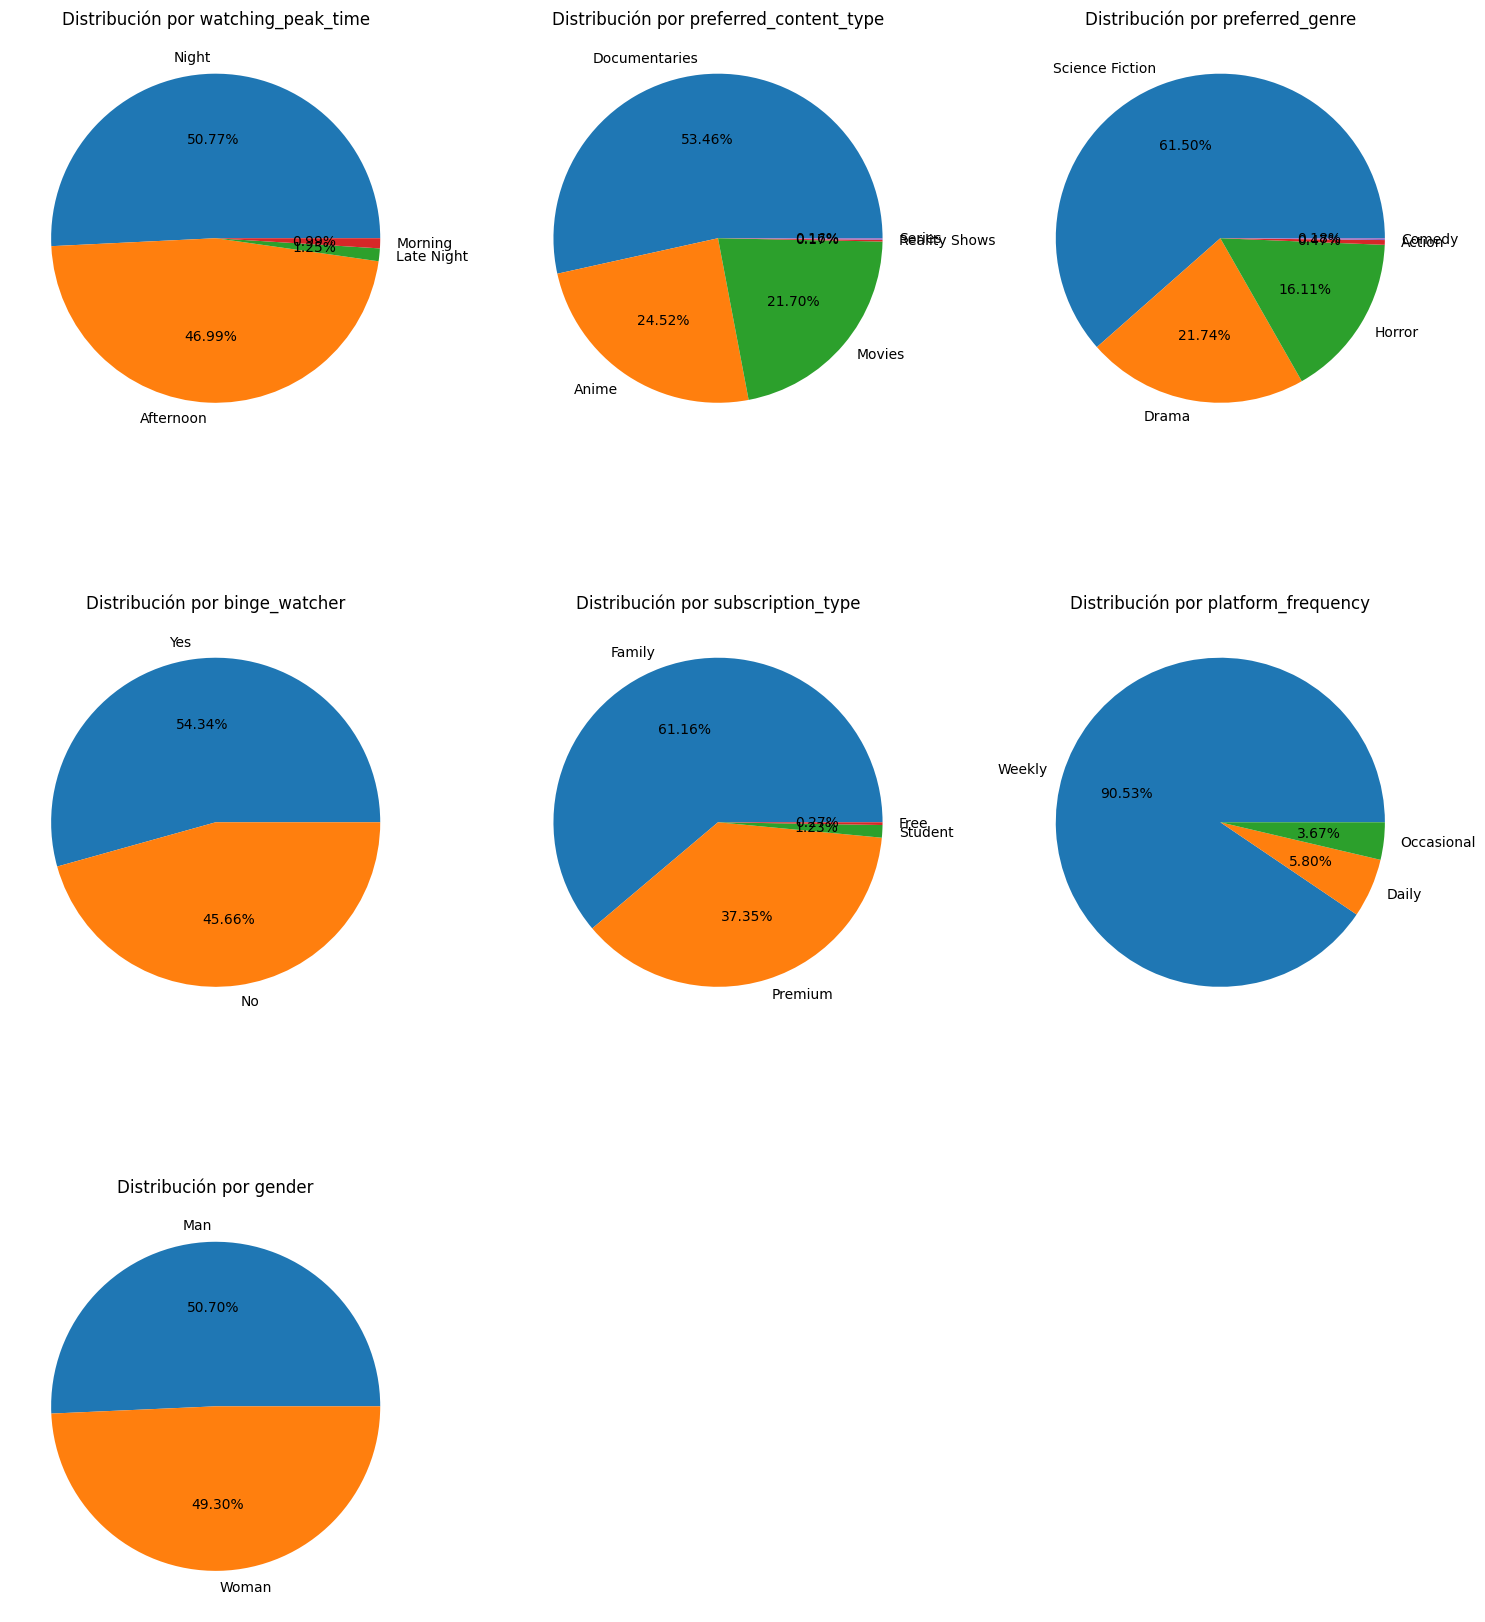

In [ ]:
"""
Género: Distribución muy equilibrada entre hombres y mujeres.
Franja horaria principal: Consumo mayoritario por la noche y por la tarde, muy bajo por la mañana y de madrugada.
Tipo de contenido preferido: Claro predominio de los documentales, seguidos del anime y las películas; realities y series casi inexistentes.
Género preferido: La ciencia ficción destaca muy por encima del drama y el terror; acción y comedia son residuales.
Tipo de suscripción: Mayoritariamente familiar y premium; las opciones gratuita y estudiante son poco utilizadas.
Frecuencia de uso: La mayoría se conecta semanalmente, con pocos usuarios diarios u ocasionales.
Binge-watching: Ligeramente más usuarios hacen sesiones largas de visualización que no.
"""

import matplotlib.pyplot as plt

# Configurar los gráficos en 3 columnas
num_cols_per_row = 3
num_rows = (len(cat_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular filas necesarias

# Crear la figura con 3 columnas
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 6 * num_rows))

# Aplanar la matriz de ejes para facilitar el recorrido
axes = axes.flatten()

# Generar gráficos de sectores para cada columna categórica
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    labels = counts.index.astype(str)

    axes[i].pie(counts, labels=labels, autopct='%.2f%%')
    axes[i].set_title(f'Distribución por {col}')

# Ocultar ejes vacíos si el número de categorías es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

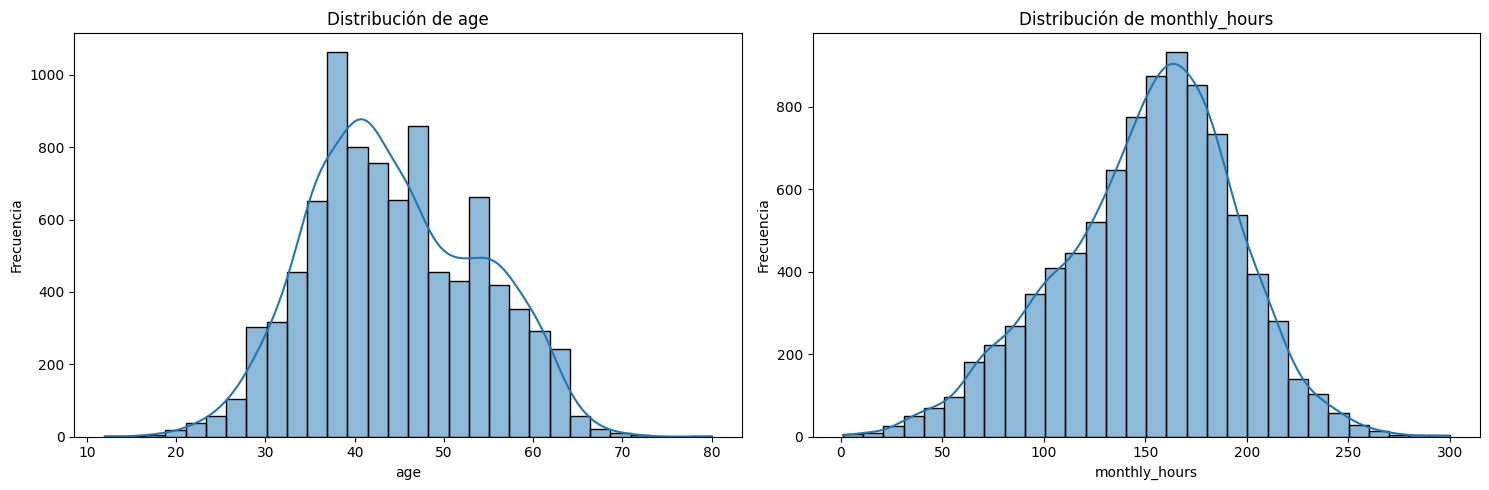

In [ ]:
"""
Edad: Distribución asimétrica con un pico antes de los 40 años, algo por debajo. Mayor concentración de usuarios entre los 30 y 50 años.
Horas mensuales: Distribución casi normal centrada en torno a las 170 horas mensuales, con pocos usuarios en los extremos.
"""
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar gráficos en 2 columnas
num_cols_per_row = 2
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row

# Crear la figura con los subgráficos
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))

# Aplanar la matriz de ejes para facilitar el recorrido
axes = axes.flatten()

# Generar histograma con KDE para cada columna numérica
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar ejes vacíos si el número de columnas es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Outliers

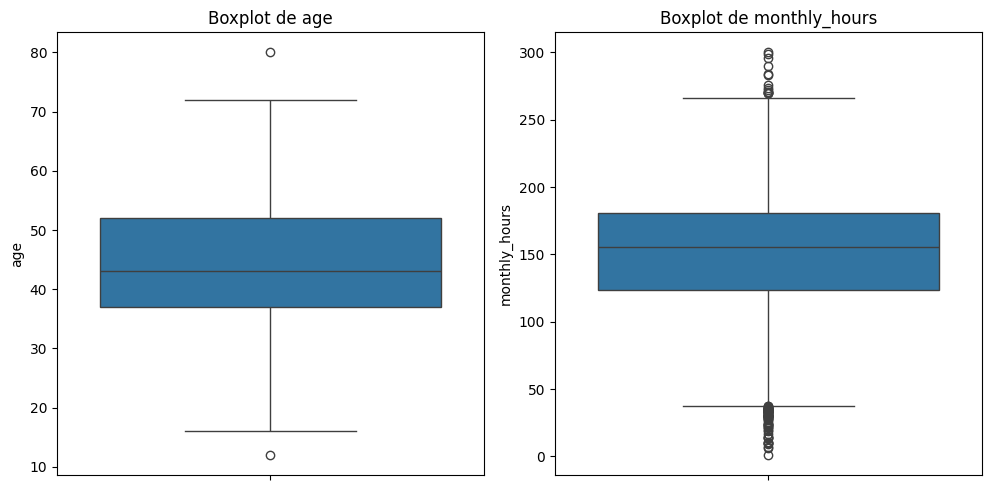

In [ ]:
"""
Edad: Hay algunos valores extremos por debajo de los 20 y por encima de los 70 años.
Horas mensuales: Varios valores extremos por debajo de las 50 y por encima de las 250 horas.
"""
num_cols_per_row = 3
num_rows = (len(num_cols) + num_cols_per_row - 1) // num_cols_per_row  # Calcular número de filas necesarias

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))
axes = axes.flatten()

# Generar boxplots para cada variable numérica
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

# Eliminar ejes vacíos si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Vamos a ver cuántos valores atípicos hay
"""
Como no son muchos, podemos eliminarlos o intentar conservarlos, ya que podrían representar casos reales y no distorsionar el modelo.
Vamos a intentar conservarlos.
"""

def count_outliers(df, num_cols):
    outlier_counts = {}

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)

    return outlier_counts

# Calcular y mostrar el número de outliers por columna numérica
outliers = count_outliers(df, num_cols)

for col, count in outliers.items():
    print(f'Número de outliers en {col}: {count}')


Número de outliers en age: 2
Número de outliers en monthly_hours: 84


In [ ]:
"""
Escalado de las columnas numéricas con MinMax porque tienen rangos diferentes y
OneHotEncoder para las categóricas porque no tienen un orden natural.
"""

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import pandas as pd

scalers = {}
encoders = {}

# Escalar columnas numéricas con MinMaxScaler
df_scaled_num = df[num_cols].copy()
for col in num_cols:
    scaler = MinMaxScaler()
    df_scaled_num[col] = scaler.fit_transform(df[[col]])
    scalers[col] = scaler

# Codificar columnas categóricas con OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
df_scaled_cat = pd.DataFrame(
    encoder.fit_transform(df[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

encoders['onehot'] = encoder

# Concatenar ambos DataFrames asegurando el mismo índice
df_escalado = pd.concat([df_scaled_num, df_scaled_cat], axis=1)

print(df_escalado.head())

        age  monthly_hours  watching_peak_time_Late Night  \
0  0.544118       0.517607                            0.0   
1  0.617647       0.758142                            0.0   
2  0.367647       0.453859                            0.0   
3  0.602941       0.473670                            0.0   
4  0.294118       0.663645                            0.0   

   watching_peak_time_Morning  watching_peak_time_Night  \
0                         0.0                       0.0   
1                         0.0                       0.0   
2                         0.0                       0.0   
3                         0.0                       0.0   
4                         0.0                       0.0   

   preferred_content_type_Documentaries  preferred_content_type_Movies  \
0                                   0.0                            1.0   
1                                   0.0                            1.0   
2                                   1.0                 

## Mirar correlaciones

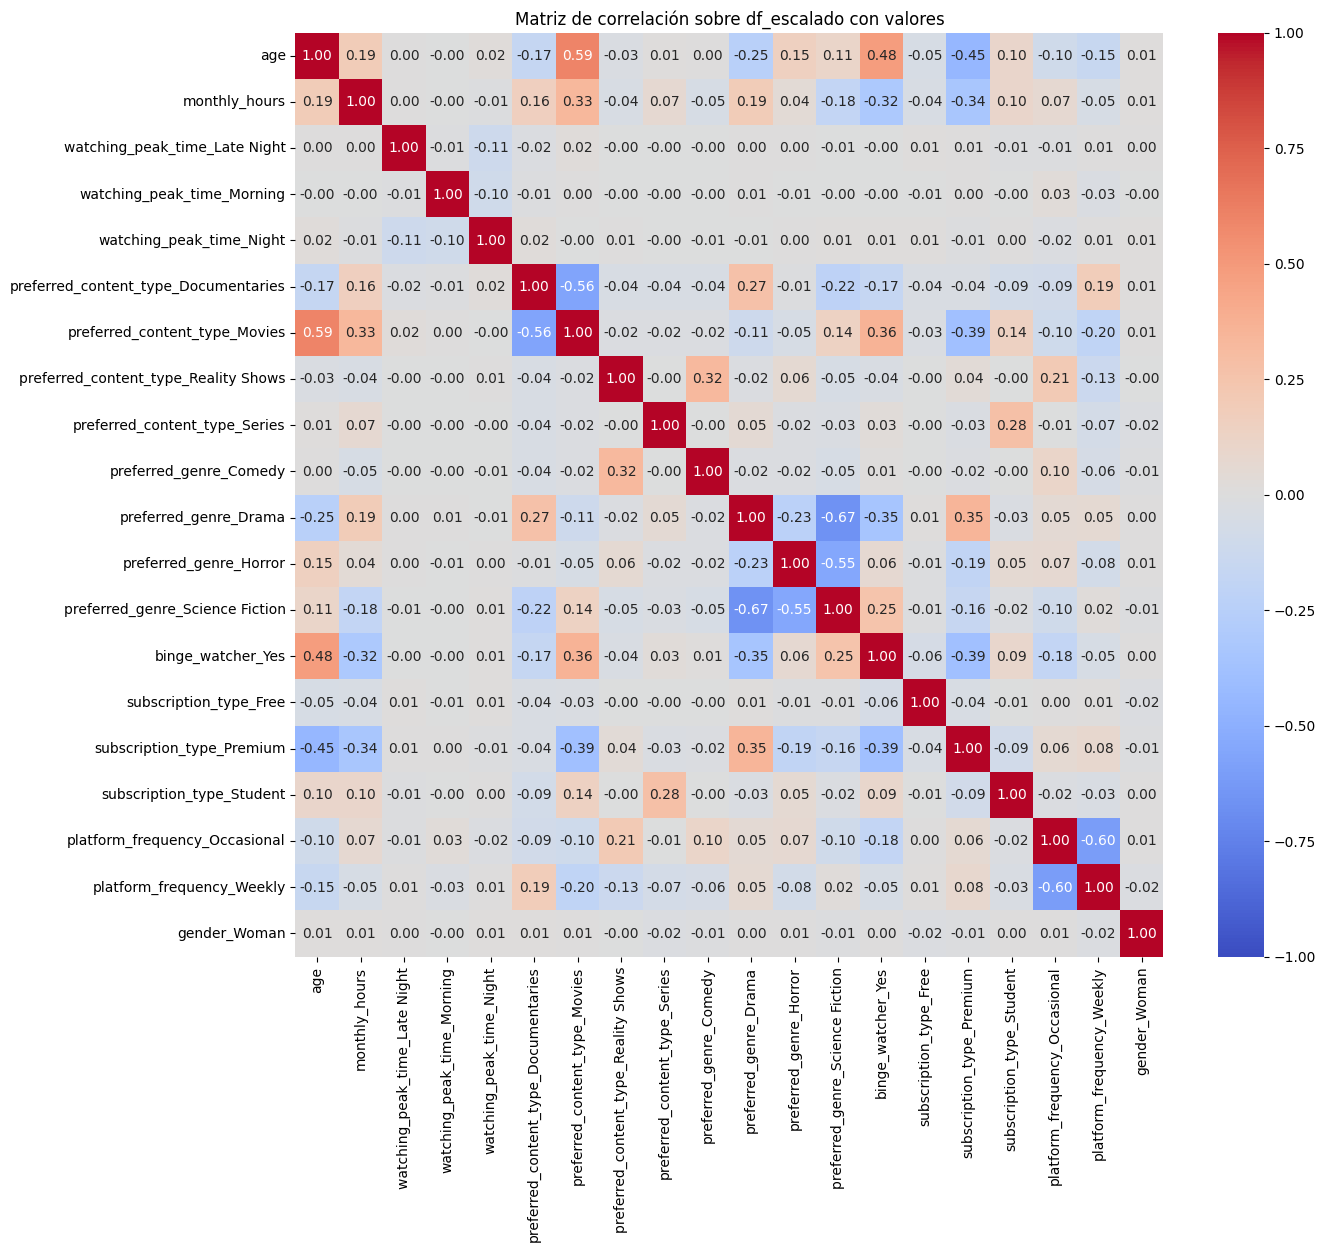

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
sns.heatmap(df_escalado.corr(),
            cmap='coolwarm',
            center=0,
            vmax=1,
            vmin=-1,
            annot=True,
            fmt=".2f")  # muestra números con 2 decimales
plt.title("Matriz de correlación sobre df_escalado con valores")
plt.show()

Se decide no eliminar ninguna característica porque, aunque algunas muestran una correlación moderada, esto se debe al proceso de codificación One-Hot o a que representan conceptos distintos. Todas son necesarias para interpretar adecuadamente los clústers posteriormente.

# Fase 3. División de los datos de entrenamiento y prueba
En aprendizaje no supervisado no existe esta fase.


# Fase 4. Entrenamiento del modelo y realización de predicciones K-MEANS y Fase 5. Validación del modelo

In [ ]:
"""
n_clusters = 5 para probar con 5 grupos

n_init = 10 indica que el algoritmo K-Means se iniciará 10 veces con centroides iniciales distintos,
y se seleccionará el modelo con la menor inercia (suma de las distancias cuadradas dentro del clúster)

max_iter = 500 significa que el algoritmo K-Means intentará ajustar los centroides hasta un máximo de 500 iteraciones por inicialización.
Esto es útil en conjuntos de datos donde puede tardar más en converger o si se quiere limitar el tiempo de ejecución

init = 'k-means++' determina cómo se inicializan los centroides. Es la opción mejorada por defecto

algorithm = 'lloyd' especifica el algoritmo usado para calcular los clústeres.
Equivale al método clásico de k-means, no es necesario especificarlo porque ya es el valor por defecto
"""
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=42,
    algorithm='lloyd'
)

# Calcular los clústeres y guardar las etiquetas en el DataFrame
kmeans_labels = kmeans.fit_predict(df_escalado)
df_escalado['kmeans_labels'] = kmeans_labels

In [ ]:
df_escalado

,age,monthly_hours,watching_peak_time_Late Night,watching_peak_time_Morning,watching_peak_time_Night,preferred_content_type_Documentaries,preferred_content_type_Movies,preferred_content_type_Reality Shows,preferred_content_type_Series,preferred_genre_Comedy,...,preferred_genre_Horror,preferred_genre_Science Fiction,binge_watcher_Yes,subscription_type_Free,subscription_type_Premium,subscription_type_Student,platform_frequency_Occasional,platform_frequency_Weekly,gender_Woman,kmeans_labels
0,0.544118,0.517607,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,4
1,0.617647,0.758142,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4
2,0.367647,0.453859,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,0.602941,0.473670,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2
4,0.294118,0.663645,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,0.352941,0.547842,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,4
9996,0.455882,0.579953,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
9997,0.529412,0.734290,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
9998,0.485294,0.530786,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2


In [ ]:
# Cálculo de métricas internas

# Calcular el coeficiente de Silhouette
silhouette = silhouette_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Silhouette Score: {silhouette}")

# Calcular el coeficiente de Davies-Bouldin
davies_bouldin = davies_bouldin_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Davies-Bouldin Score: {davies_bouldin}")

# Calcular el coeficiente de Calinski-Harabasz
calinski_harabasz = calinski_harabasz_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

# Obtener la inercia (SSE)
inertia = kmeans.inertia_
print(f"Inercia (SSE): {inertia}")

Silhouette Score: 0.3938688938548339
Davies-Bouldin Score: 1.1353795595809992
Calinski-Harabasz Score: 6123.512441257227
Inercia (SSE): 10223.106264102169


# Fase 6 y Fase 7. Optimización del modelo y prueba del nuevo modelo K-MEANS

In [ ]:
df_escalado = df_escalado.drop(['kmeans_labels'], axis=1)

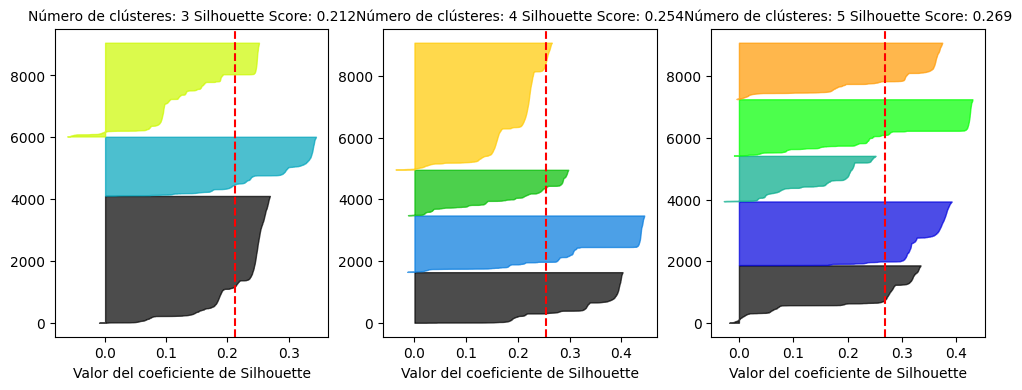

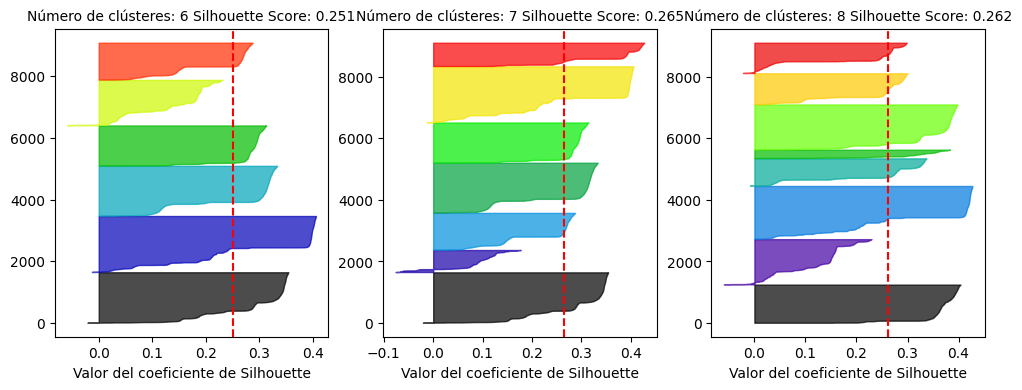

In [ ]:
"""
Parece que los valores óptimos oscilan entre 5, 6 y 7 clústeres.
La elección final depende del nivel de detalle que se quiera obtener
en las características de cada grupo.  De todas formas, antes de decidir el número de clústeres
haremos más pruebas.
"""

# Creación de una función para encontrar el valor óptimo de k
def visualize_silhouette(model, cluster_lists, X_features):

    n_cols = len(cluster_lists)

    fig, axs = plt.subplots(figsize=(4*n_cols,4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):

        cluster = KMeans(n_clusters=n_cluster, n_init=10, max_iter=500, random_state=42, algorithm='lloyd')
        cluster_labels = cluster.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Número de clústeres: '+str(n_cluster) + ' Silhouette Score: '+ str(round(sil_avg,3)),
                           fontsize=10)
        axs[ind].set_xlabel('Valor del coeficiente de Silhouette')

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color=  cm.nipy_spectral(float(i)/n_cluster)
            axs[ind].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_sil_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
            y_lower = y_upper + 10
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

"""
La altura de cada "cuchillo" indica el número de instancias
El ancho indica los coeficientes
La línea discontinua indica la puntuación media de Silhouette para cada clúster
Todos los clústeres deben superarla; si no, no se consideran buenos
"""

visualize_silhouette('KMeans', [3,4,5], df_escalado)
visualize_silhouette('KMeans', [6,7,8], df_escalado)


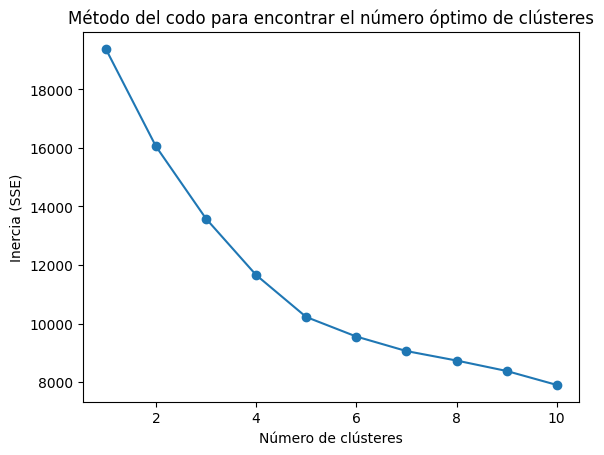

In [ ]:
# Elbow para corroborar los gráficos anteriores k=5
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=500, random_state=42, algorithm='lloyd')
    kmeans.fit(df_escalado)
    sse.append(kmeans.inertia_)

# Visualizar la curva del codo
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia (SSE)')
plt.title('Método del codo para encontrar el número óptimo de clústeres')
plt.show()

In [ ]:
# Decidimos usar 5 clústeres
kmeans = KMeans(n_clusters=5, n_init=10, init='k-means++', max_iter=500, random_state=42, algorithm='lloyd')
kmeans_labels = kmeans.fit_predict(df_escalado)
df_escalado['kmeans_labels'] = kmeans_labels

# Cálculo de métricas internas

# Calcular el coeficiente de Silhouette
silhouette = silhouette_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Silhouette Score: {silhouette}")

# Calcular el coeficiente de Davies-Bouldin
davies_bouldin = davies_bouldin_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Davies-Bouldin Score: {davies_bouldin}")

# Calcular el coeficiente de Calinski-Harabasz
calinski_harabasz = calinski_harabasz_score(df_escalado, df_escalado['kmeans_labels'])
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

# Obtener la inercia (SSE)
inertia = kmeans.inertia_
print(f"Inercia (SSE): {inertia}")


Silhouette Score: 0.3938688938548339
Davies-Bouldin Score: 1.1353795595809992
Calinski-Harabasz Score: 6123.512441257227
Inercia (SSE): 10223.106264102169


In [ ]:
df['kmeans_labels'] = df_escalado['kmeans_labels'].values

Valores únicos en la columna "kmeans_labels":
kmeans_labels
1    2059
0    1858
4    1822
3    1822
2    1468
Name: count, dtype: int64


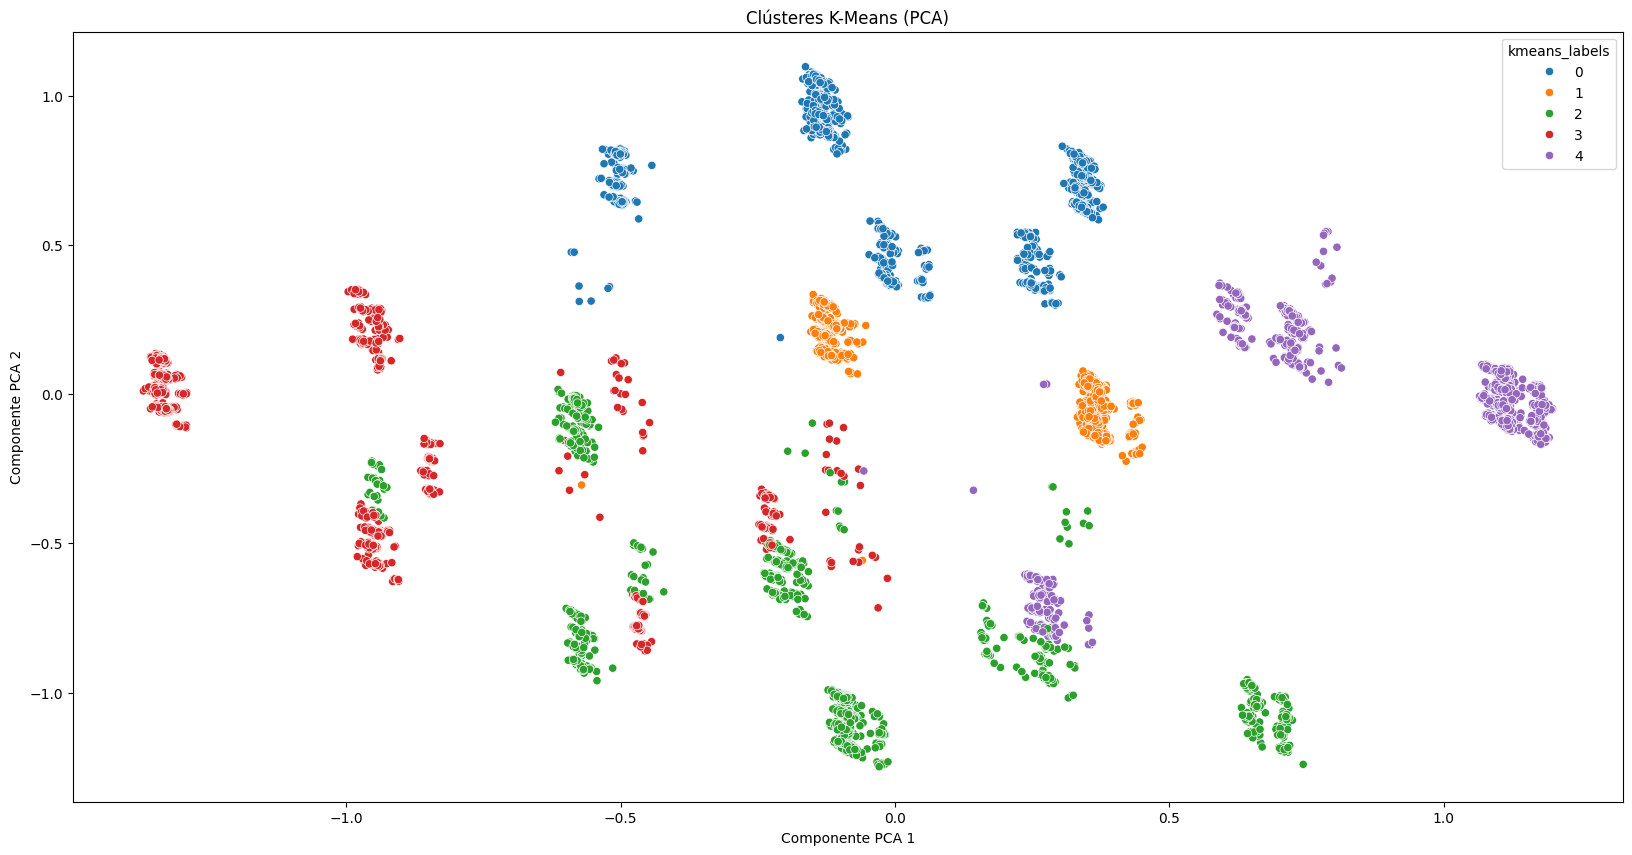

In [ ]:
"""
Parece que PCA a partir de los clústeres de KMeans no separa demasiado bien.
"""

# Representamos gráficamente los 7 clústeres sin aplicar escalado adicional
nuevo_df = pd.DataFrame()
nuevo_df['kmeans_labels'] = df_escalado['kmeans_labels'].copy()

columna_seleccionada = 'kmeans_labels'

# Obtener los valores únicos y sus frecuencias
unique_values = nuevo_df[columna_seleccionada].value_counts()

# Imprimir los valores únicos y sus frecuencias
print(f'Valores únicos en la columna "{columna_seleccionada}":')
print(unique_values)

# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_escalado.drop(columns=['kmeans_labels']))
nuevo_df['PCA1'] = df_pca[:, 0]
nuevo_df['PCA2'] = df_pca[:, 1]

# Representar gráficamente los clústeres en 2D
plt.figure(figsize=(20, 10))
sns.scatterplot(x='PCA1', y='PCA2', hue='kmeans_labels', data=nuevo_df, palette='tab10', legend='full')
plt.title('Clústeres K-Means (PCA)')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.show()


# Fase 4. Entrenamiento del modelo y realización de predicciones AGNES y Fase 5. Validación del modelo


In [ ]:
# Eliminamos los clústeres formados por KMeans
df_escalado = df_escalado.drop(columns=['kmeans_labels'], axis=1)

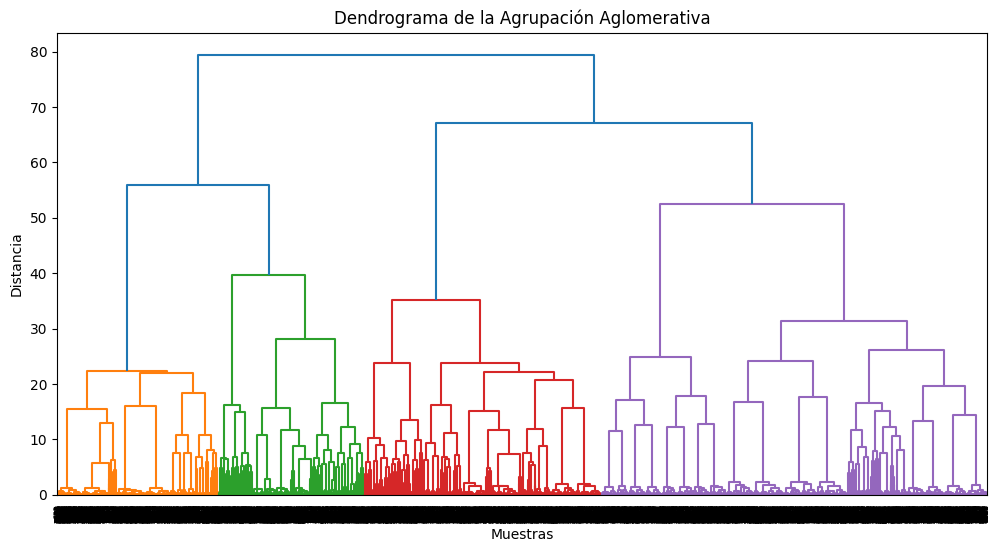

In [ ]:
# 4/5/6
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

# Cálculo de la matriz de enlace
linkage_matrix = linkage(df_escalado, method='ward')

# Visualización del dendrograma
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title('Dendrograma de la Agrupación Aglomerativa')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

| Clústers | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
| -------- | ------------ | ---------------- | ------------------- |
| **5**    | 0.353        | 1.230            | 4963.39             |
| **6**    | 0.413        | 1.273            | 6983.89             |
| **7**    | **0.418**    | **1.126**        | 6330.68             |
| **8**    | 0.402        | 1.230            | **8145.49**         |

k = 7 ofrece el mejor equilibrio global entre separación (Silhouette), compacidad (Davies-Bouldin) y estabilidad (Calinski-Harabasz).

In [ ]:

# Crear una instancia del modelo de agrupación aglomerativa
agglomerative_model = AgglomerativeClustering(n_clusters=7, linkage='ward')

# Entrenar el modelo con los datos de entrada
clusters = agglomerative_model.fit_predict(df_escalado)
labels_agglo = agglomerative_model.fit_predict(df_escalado)
df_escalado['Cluster'] = labels_agglo

# Cálculo de métricas internas

# Calcular el coeficiente de Silhouette
silhouette = silhouette_score(df_escalado, df_escalado['Cluster'])
print(f"Silhouette Score: {silhouette}")

# Calcular el coeficiente de Davies-Bouldin
davies_bouldin = davies_bouldin_score(df_escalado, df_escalado['Cluster'])
print(f"Davies-Bouldin Score: {davies_bouldin}")

# Calcular el coeficiente de Calinski-Harabasz
calinski_harabasz = calinski_harabasz_score(df_escalado, df_escalado['Cluster'])
print(f"Calinski-Harabasz Score: {calinski_harabasz}")


Silhouette Score: 0.414617381705982
Davies-Bouldin Score: 1.1345677706819284
Calinski-Harabasz Score: 6394.496386411033


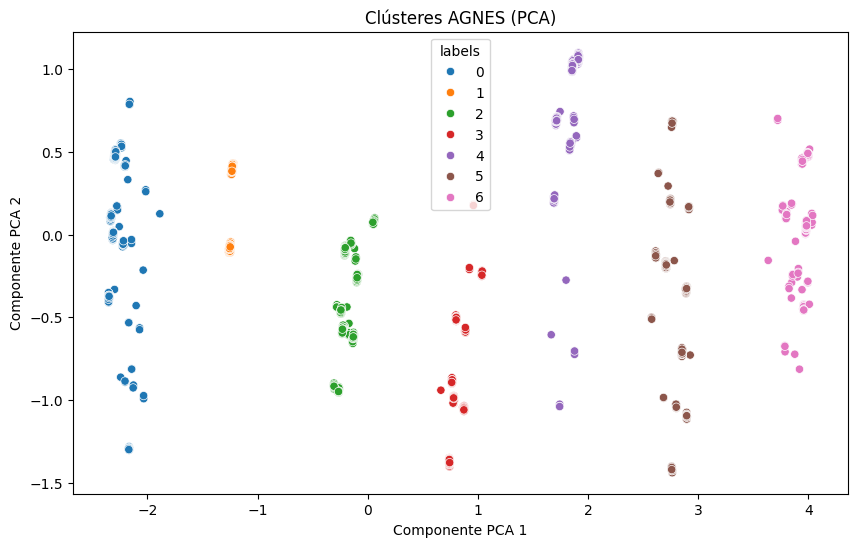

In [ ]:
# Visualizamos los clústeres con PCA
nuevo_df_agnes = pd.DataFrame()
nuevo_df_agnes['labels'] = labels_agglo

# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
df_pca_agnes = pca.fit_transform(df_escalado)
nuevo_df_agnes['PCA1'] = df_pca_agnes[:, 0]
nuevo_df_agnes['PCA2'] = df_pca_agnes[:, 1]

# Representación gráfica de los clústeres
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='labels', data=nuevo_df_agnes, palette='tab10', legend='full')
plt.title('Clústeres AGNES (PCA)')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.show()

# Fase 4. Entrenamiento del modelo y realización de predicciones DBSCAN y Fase 5. Validación del modelo del model y Fase 6 y Fase 7. Optimización del modelo y prueba del nuevo modelo DBSCAN

In [ ]:
# Probamos DBSCAN con valores iniciales para eps y min_samples y distintos escalados
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Crear una instancia de DBSCAN
dbscan_model = DBSCAN(eps=0.5, min_samples=5)

# Entrenar el modelo con los datos escalados
labels_dbscan = dbscan_model.fit_predict(df_escalado)
df['Cluster'] = labels_dbscan

"""
Silhouette Score: 0.85 → altísimo → los clústeres están muy bien separados y compactos

Davies-Bouldin: 0.20 → bajísimo → indica mínima superposición entre clústeres

Calinski-Harabasz: 16885 → muy alto → los grupos están muy definidos internamente y muy separados entre sí
"""

# Cálculo de métricas internas
# Solo se calculan para grupos bien definidos (no se incluyen los outliers etiquetados como -1)
valid_clusters = df['Cluster'] != -1  # Excluimos los outliers (etiqueta -1)

if valid_clusters.sum() > 0:  # Aseguramos que hay grupos válidos
    silhouette = silhouette_score(df_escalado[valid_clusters], df['Cluster'][valid_clusters])
    davies_bouldin = davies_bouldin_score(df_escalado[valid_clusters], df['Cluster'][valid_clusters])
    calinski_harabasz = calinski_harabasz_score(df_escalado[valid_clusters], df['Cluster'][valid_clusters])

    print(f"Silhouette Score: {silhouette}")
    print(f"Davies-Bouldin Score: {davies_bouldin}")
    print(f"Calinski-Harabasz Score: {calinski_harabasz}")
else:
    print("No hay suficientes clústeres válidos para calcular las métricas.")

print(f"Labels : {sorted(int(i) for i in df['Cluster'].unique())}")

# Eliminamos la columna temporal de clústeres
df = df.drop(['Cluster'], axis=1)

Silhouette Score: 0.8518207258448314
Davies-Bouldin Score: 0.20547097762436997
Calinski-Harabasz Score: 17582.117812532677
Labels : [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172]


In [ ]:
"""
La combinación eps=0.3 y min_samples= o eps=0.5 y min_samples=3 parecen ser una buena opción, pero saldrian muuuchos clústeres.
"""

# Probamos DBSCAN buscando la mejor combinación para eps y min_samples
eps_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

for eps in eps_values:
    for min_samples in min_samples_values:
        # Configura el modelo DBSCAN con los valores actuales de eps y min_samples
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels_dbscan = dbscan.fit_predict(df_escalado)

        # Comprueba si hay más de un clúster válido
        n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
        if n_clusters_dbscan > 1:
            # Calcula la puntuación de Silhouette
            silhouette_avg_dbscan = silhouette_score(df_escalado, labels_dbscan)
            # Calcula el coeficiente de Calinski-Harabasz
            calinski_harabasz_dbscan = calinski_harabasz_score(df_escalado, labels_dbscan)
            print(f"DBSCAN con eps={eps}, min_samples={min_samples} - Silhouette: {silhouette_avg_dbscan}, Calinski-Harabasz: {calinski_harabasz_dbscan}")
        else:
            print(f"Con eps={eps}, min_samples={min_samples}, DBSCAN no encontró más de un clúster válido.")

DBSCAN con eps=0.01, min_samples=3 - Silhouette: -0.5980556099128369, Calinski-Harabasz: 3.504666305281859
DBSCAN con eps=0.01, min_samples=5 - Silhouette: -0.636947717267268, Calinski-Harabasz: 4.356317971298868
Con eps=0.01, min_samples=10, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=20, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=30, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=40, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=50, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=60, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=70, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=80, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=90, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=100, DBSCAN no encontró más de un clúster válido.
Con eps=0.01, min_samples=110, DBSCA

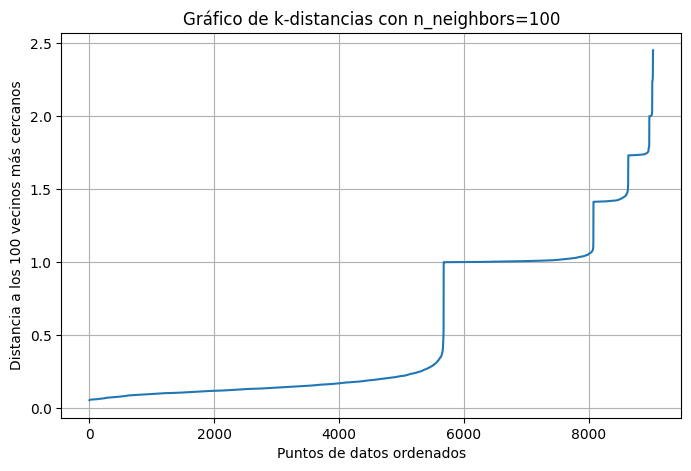

In [ ]:
"""
El codo parece estar alrededor de eps = 1.0, pero también hay otro antes sobre 0.3 y 0.4
"""

# Reconfirmamos con una gráfica de k-distancias para encontrar el valor óptimo de eps
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN

import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Definir el número de vecinos a usar (n_neighbors = min_samples)
n_neighbors = 100

# Calcular las distancias para el número de vecinos definido
neigh = NearestNeighbors(n_neighbors=n_neighbors)
neigh.fit(df_escalado)
distances, indices = neigh.kneighbors(df_escalado)

# Ordenar las distancias de mayor a menor para crear la gráfica
distances = np.sort(distances[:, n_neighbors - 1])

# Crear la gráfica
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Puntos de datos ordenados')
plt.ylabel(f'Distancia a los {n_neighbors} vecinos más cercanos')
plt.title(f'Gráfico de k-distancias con n_neighbors={n_neighbors}')
plt.grid(True)
plt.show()

In [ ]:
# Se hacen varias pruebas con eps y min_samples
# Parece que al reducir min_samples no detecta el clúster -1 y genera demasiados clústeres, se decide usar 5

dbscan_model = DBSCAN(eps=1.2, min_samples=200).fit(df_escalado)
labels = dbscan_model.labels_
print('Labels :', sorted(int(i) for i in set(dbscan_model.labels_)))

Labels : [-1, 0, 1, 2, 3, 4]


In [ ]:
# Preparem reducció dimensionalitat per a graficar dades
nuevo_df_dbscan = pd.DataFrame()
nuevo_df_dbscan['labels'] = labels

# Reducció de dimensionalitat amb PCA
pca = PCA(n_components=2)
pca_dbscan = pca.fit_transform(df_escalado)
nuevo_df_dbscan['PCA1'] = pca_dbscan[:, 0]
nuevo_df_dbscan['PCA2'] = pca_dbscan[:, 1]

nuevo_df_dbscan

,labels,PCA1,PCA2
0,-1,3.979447,0.044750
1,0,1.839264,0.540441
2,1,-2.292980,0.466425
3,2,-0.203654,-0.097191
4,0,1.830359,0.514177
...,...,...,...
9024,0,1.852956,0.991451
9025,1,-2.347942,-0.373353
9026,1,-2.308895,0.013539
9027,-1,-0.131644,-0.618832


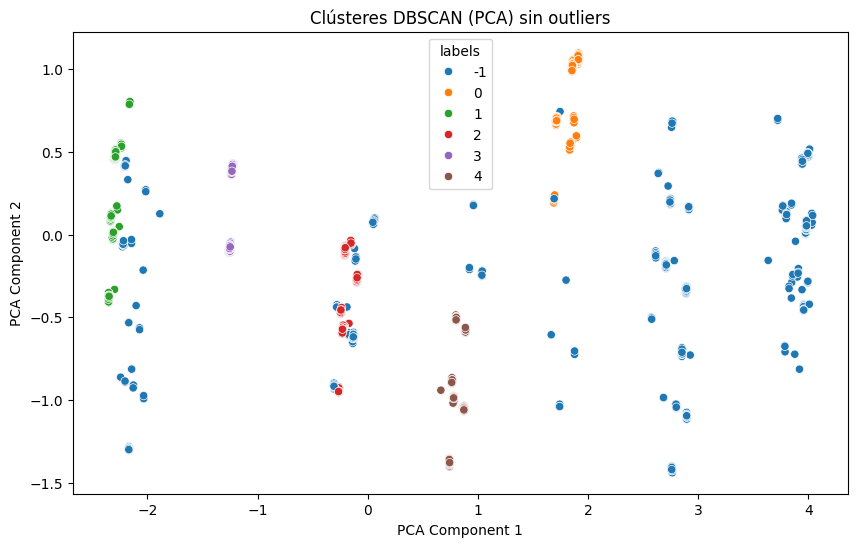

In [ ]:
# Gráfico de los clústeres
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='labels', data=nuevo_df_dbscan, palette='tab10', legend='full')
plt.title('Clústeres DBSCAN (PCA) sin outliers')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

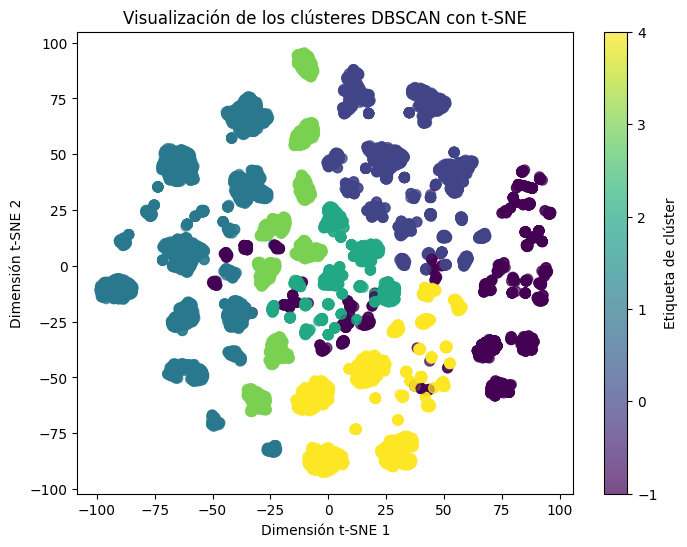

In [ ]:
# Probamos otras visualizaciones que creemos más adecuadas para reducción de dimensionalidad no lineal
# t-SNE
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Aplicar t-SNE para reducir a 2 dimensiones
tsne = TSNE(n_components=2, random_state=42)
music_df_tsne = tsne.fit_transform(df_escalado)

# Crear un gráfico de dispersión de los clústeres usando t-SNE
plt.figure(figsize=(8, 6))
plt.scatter(music_df_tsne[:, 0], music_df_tsne[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("Visualización de los clústeres DBSCAN con t-SNE")
plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")
plt.colorbar(label='Etiqueta de clúster')
plt.show()

# Fase 8. Conclusiones


Nos quedamos con el modelo aglomerativo con 7 clústeres tras analizar las métricas, ya que la visualización en PCA muestra una separación muy clara entre los grupos.

# Representación gráfica y qualitativa de los clústeres

In [ ]:
# Cargar dataset
ruta = '/content/drive/MyDrive/JE-UOC/CSV/streaming_usage_dataset.csv'
df = pd.read_csv(ruta)

# Eliminar columna ID
df = df.drop(["user_id"], axis=1)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Eliminar valores nulos
df.dropna(inplace=True)

# Reemplazar la coma por punto y convertir a float
df['monthly_hours'] = df['monthly_hours'].str.replace(',', '.', regex=False).astype(float)

# Mapear 0 y 1 a 'No' y 'Yes'
df['binge_watcher'] = df['binge_watcher'].map({0: 'No', 1: 'Yes'})

# Identificar columnas categóricas y numéricas
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include='number').columns.tolist()

# Escalado MinMax para numéricas
scalers = {}
df_scaled_num = df[num_cols].copy()
for col in num_cols:
    scaler = MinMaxScaler()
    df_scaled_num[col] = scaler.fit_transform(df[[col]])
    scalers[col] = scaler

# Codificación OneHot para categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
df_scaled_cat = pd.DataFrame(
    encoder.fit_transform(df[cat_cols]),
    columns=encoder.get_feature_names_out(cat_cols),
    index=df.index
)

# Concatenar escalado final
df_escalado = pd.concat([df_scaled_num, df_scaled_cat], axis=1)

# Agrupación aglomerativa
agglomerative_model = AgglomerativeClustering(n_clusters=7, linkage='ward')
labels_agglo = agglomerative_model.fit_predict(df_escalado)
df_escalado['Cluster'] = labels_agglo

# Evaluación con métricas internas
silhouette = silhouette_score(df_escalado, df_escalado['Cluster'])
davies_bouldin = davies_bouldin_score(df_escalado, df_escalado['Cluster'])
calinski_harabasz = calinski_harabasz_score(df_escalado, df_escalado['Cluster'])

print(f"Silhouette Score: {silhouette}")
print(f"Davies-Bouldin Score: {davies_bouldin}")
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

# Añadir etiquetas al DataFrame original
df['Cluster'] = df_escalado['Cluster'].values

Silhouette Score: 0.414617381705982
Davies-Bouldin Score: 1.1345677706819284
Calinski-Harabasz Score: 6394.496386411033


In [ ]:
df

,age,monthly_hours,watching_peak_time,preferred_content_type,preferred_genre,binge_watcher,subscription_type,platform_frequency,gender,Cluster
0,49.0,155.764508,Afternoon,Movies,Drama,Yes,Family,Weekly,Woman,6
1,54.0,227.684365,Afternoon,Movies,Science Fiction,No,Family,Weekly,Woman,4
2,37.0,136.703929,Afternoon,Documentaries,Science Fiction,Yes,Family,Weekly,Man,0
3,53.0,142.627440,Afternoon,Documentaries,Horror,Yes,Family,Weekly,Woman,2
4,32.0,199.429831,Afternoon,Movies,Science Fiction,No,Family,Weekly,Man,4
...,...,...,...,...,...,...,...,...,...,...
9994,36.0,164.804734,Afternoon,Movies,Science Fiction,Yes,Family,Weekly,Woman,4
9996,43.0,174.405875,Afternoon,Documentaries,Science Fiction,No,Premium,Weekly,Man,0
9997,48.0,220.552685,Night,Documentaries,Science Fiction,No,Family,Weekly,Man,0
9998,45.0,159.704952,Night,Anime,Horror,No,Premium,Weekly,Man,2


In [ ]:
# Creación de los 7 clústeres
cluster_0 = df.loc[df['Cluster']==0]
cluster_1 = df.loc[df['Cluster']==1]
cluster_2 = df.loc[df['Cluster']==2]
cluster_3 = df.loc[df['Cluster']==3]
cluster_4 = df.loc[df['Cluster']==4]
cluster_5 = df.loc[df['Cluster']==5]
cluster_6 = df.loc[df['Cluster']==6]

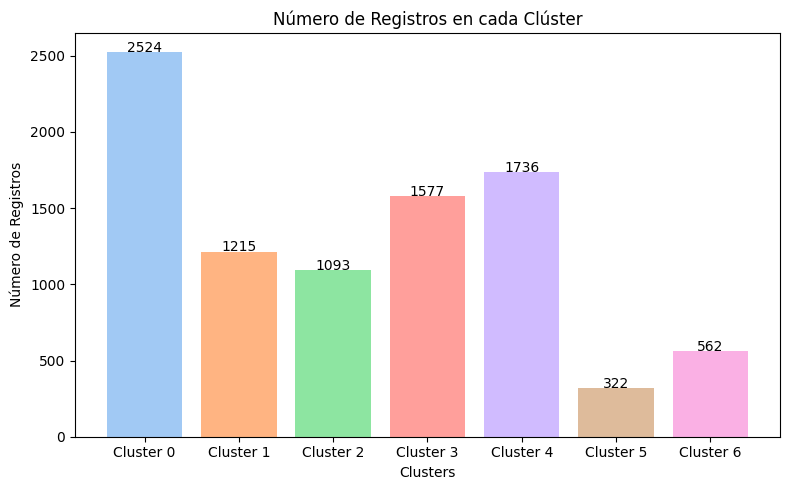

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar registros por clúster
cluster_counts = df['Cluster'].value_counts().sort_index()
clusters = [f'Cluster {i}' for i in cluster_counts.index]
num_rows = cluster_counts.values

# Paleta de colores "bonita"
colores = sns.color_palette('pastel', len(clusters))

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.bar(clusters, num_rows, color=colores)
plt.xlabel('Clusters')
plt.ylabel('Número de Registros')
plt.title('Número de Registros en cada Clúster')

# Etiquetas numéricas
for i, num in enumerate(num_rows):
    plt.text(i, num + 0.5, str(num), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

def graficar_cluster_hist(df, nombre='Clúster'):
    # Variables numéricas
    numeric_columns = ['monthly_hours', 'platform_frequency', 'age']
    num_cols = len(numeric_columns)

    fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 4))
    if num_cols == 1:
        axes = [axes]

    for i, col in enumerate(numeric_columns):
        if col in df.columns:
            counts, bins, patches = axes[i].hist(df[col], bins=10, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'Histograma de {col} - {nombre}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frecuencia')

            total = counts.sum()
            for count, patch in zip(counts, patches):
                if count > 0:
                    percent = (count / total) * 100
                    axes[i].text(patch.get_x() + patch.get_width() / 2, count,
                                 f'{int(count)} ({percent:.1f}%)',
                                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Variables categóricas
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        if col in df.columns and i < len(axes):
            counts = df[col].value_counts()
            total = counts.sum()
            bars = counts.plot(kind='bar', ax=axes[i], alpha=0.7, edgecolor='black')

            axes[i].set_title(f'Frecuencia de {col}')
            axes[i].set_ylabel("Número de usuarios")
            axes[i].set_xlabel("Categorías")

            for bar in bars.patches:
                height = bar.get_height()
                if height > 0:
                    percent = (height / total) * 100
                    axes[i].text(bar.get_x() + bar.get_width() / 2,
                                 height,
                                 f'{height:.0f} ({percent:.1f}%)',
                                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    for j in range(len(cat_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


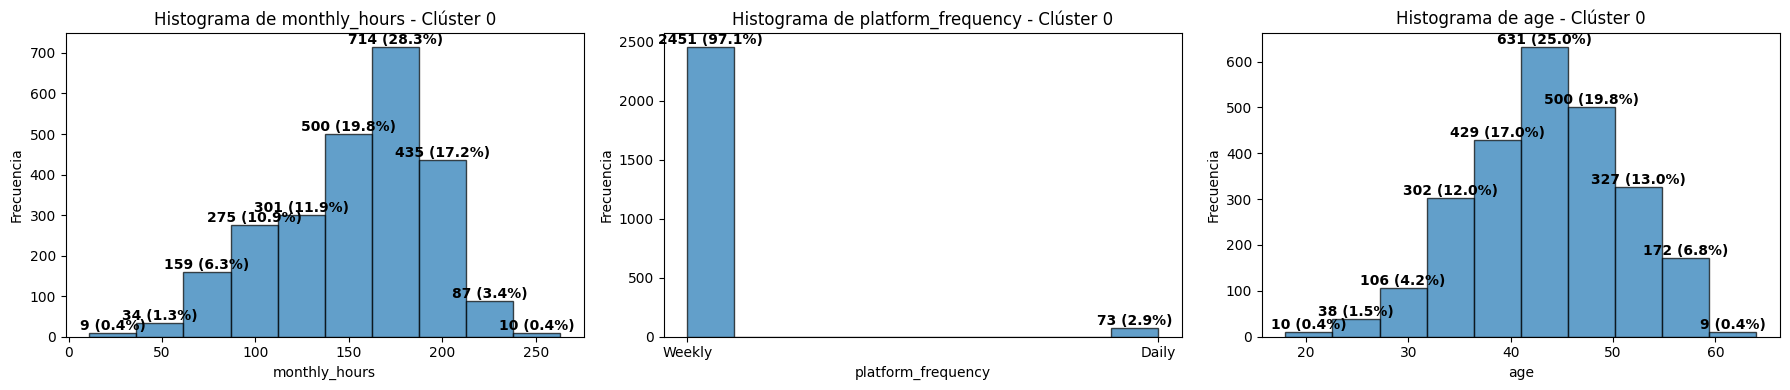

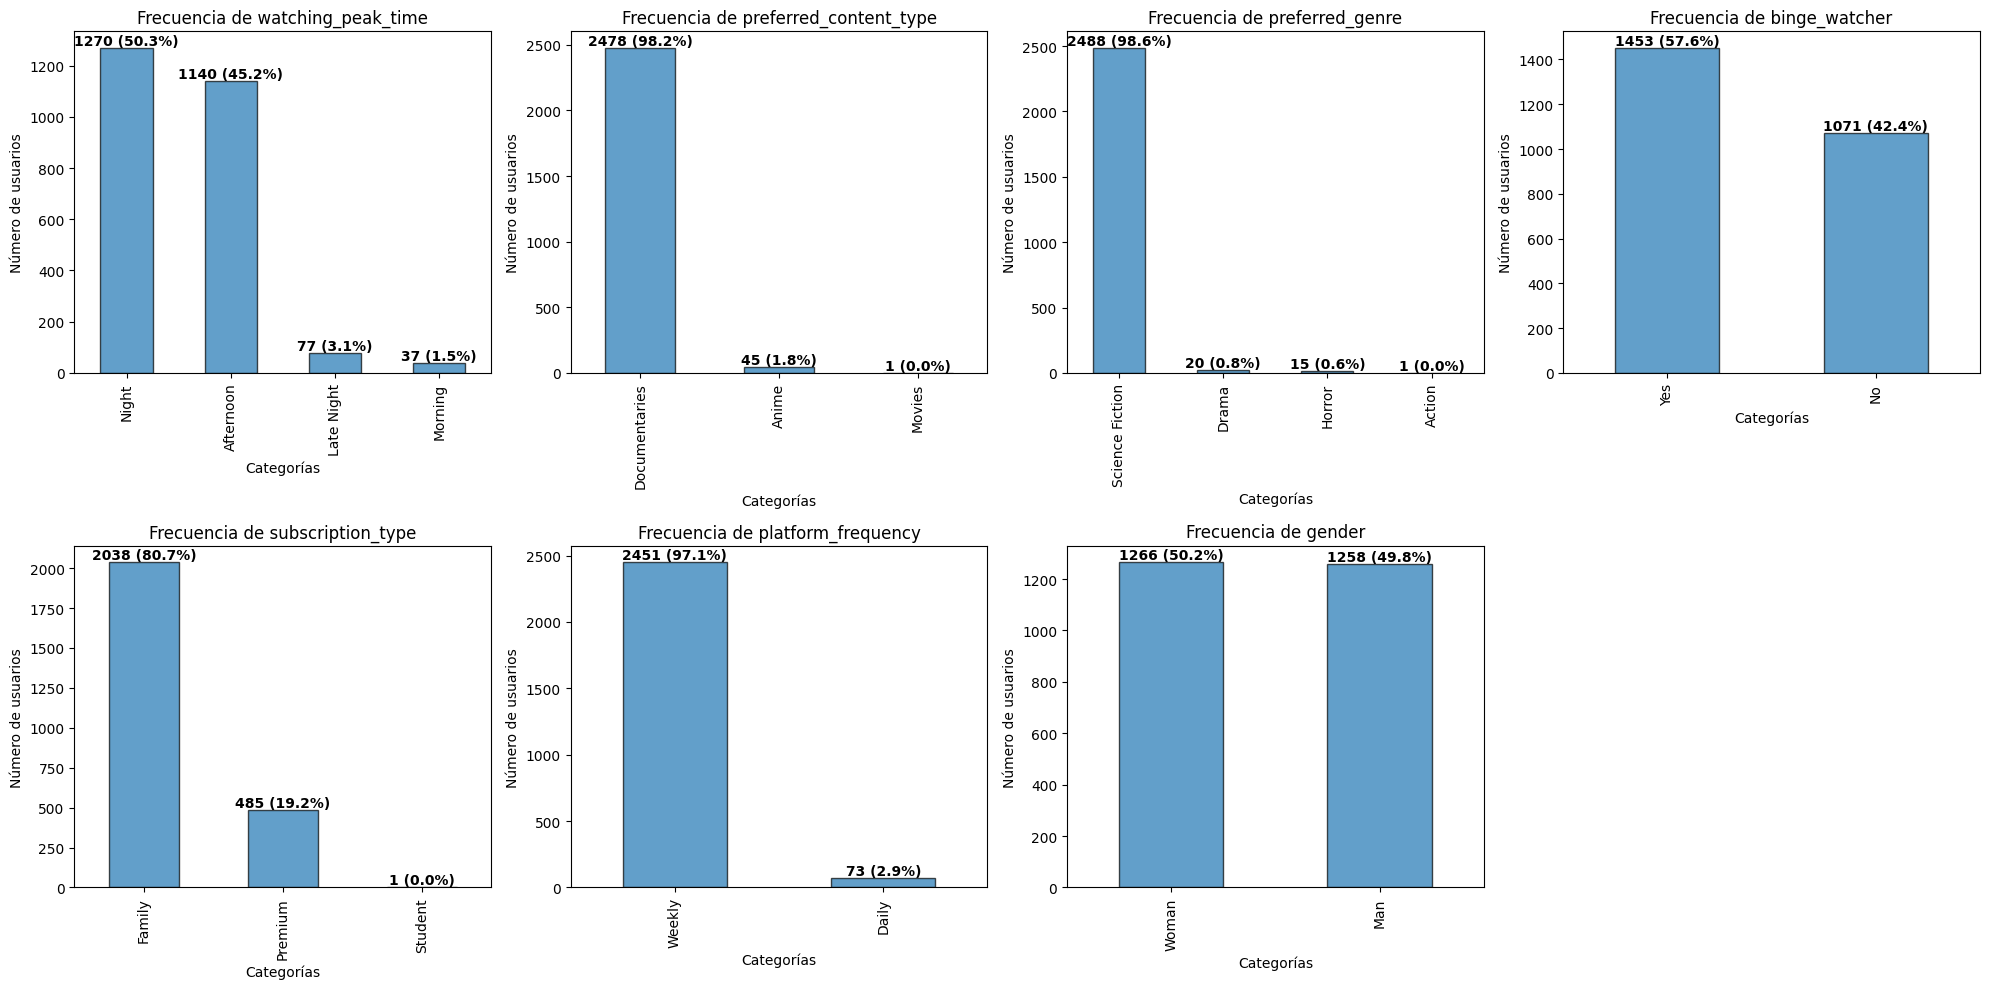

In [ ]:
graficar_cluster_hist(cluster_0, nombre='Clúster 0')

El **Clúster 0** está compuesto por hombres y mujeres en proporciones similares, con una mayoría de edad adulta entre 35 y 50 años. Su consumo mensual es moderado-alto, acceden semanalmente y la mayoría tiene suscripción familiar. Prefieren contenido de ciencia ficción, especialmente en formato documental, y ven la plataforma por la noche o la tarde. Más de la mitad hacen maratones, mientras que otros géneros y tipos de contenido tienen muy poca presencia.

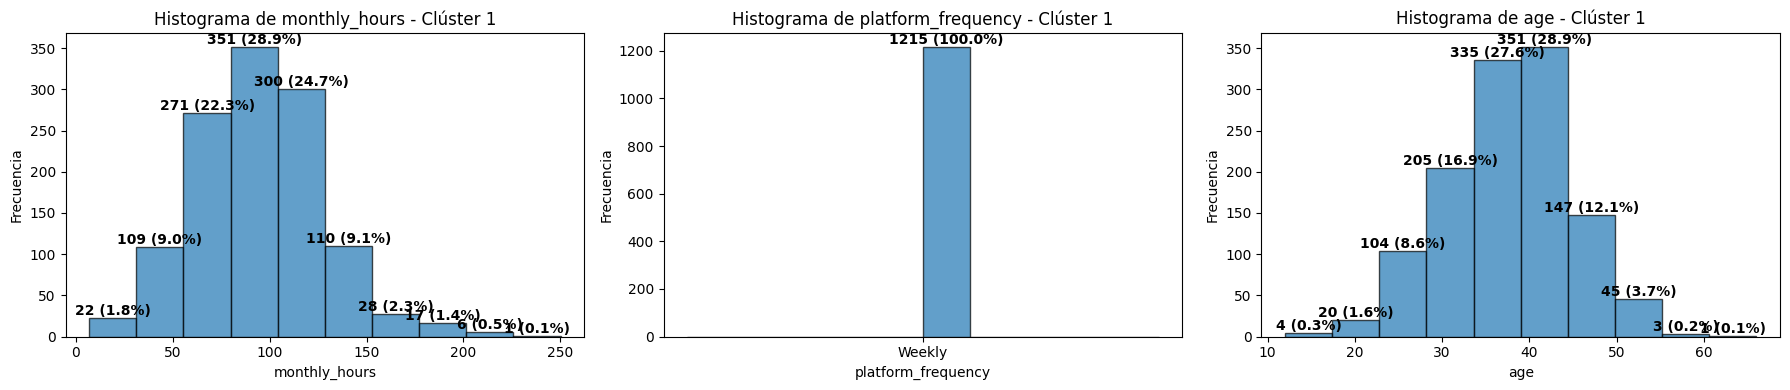

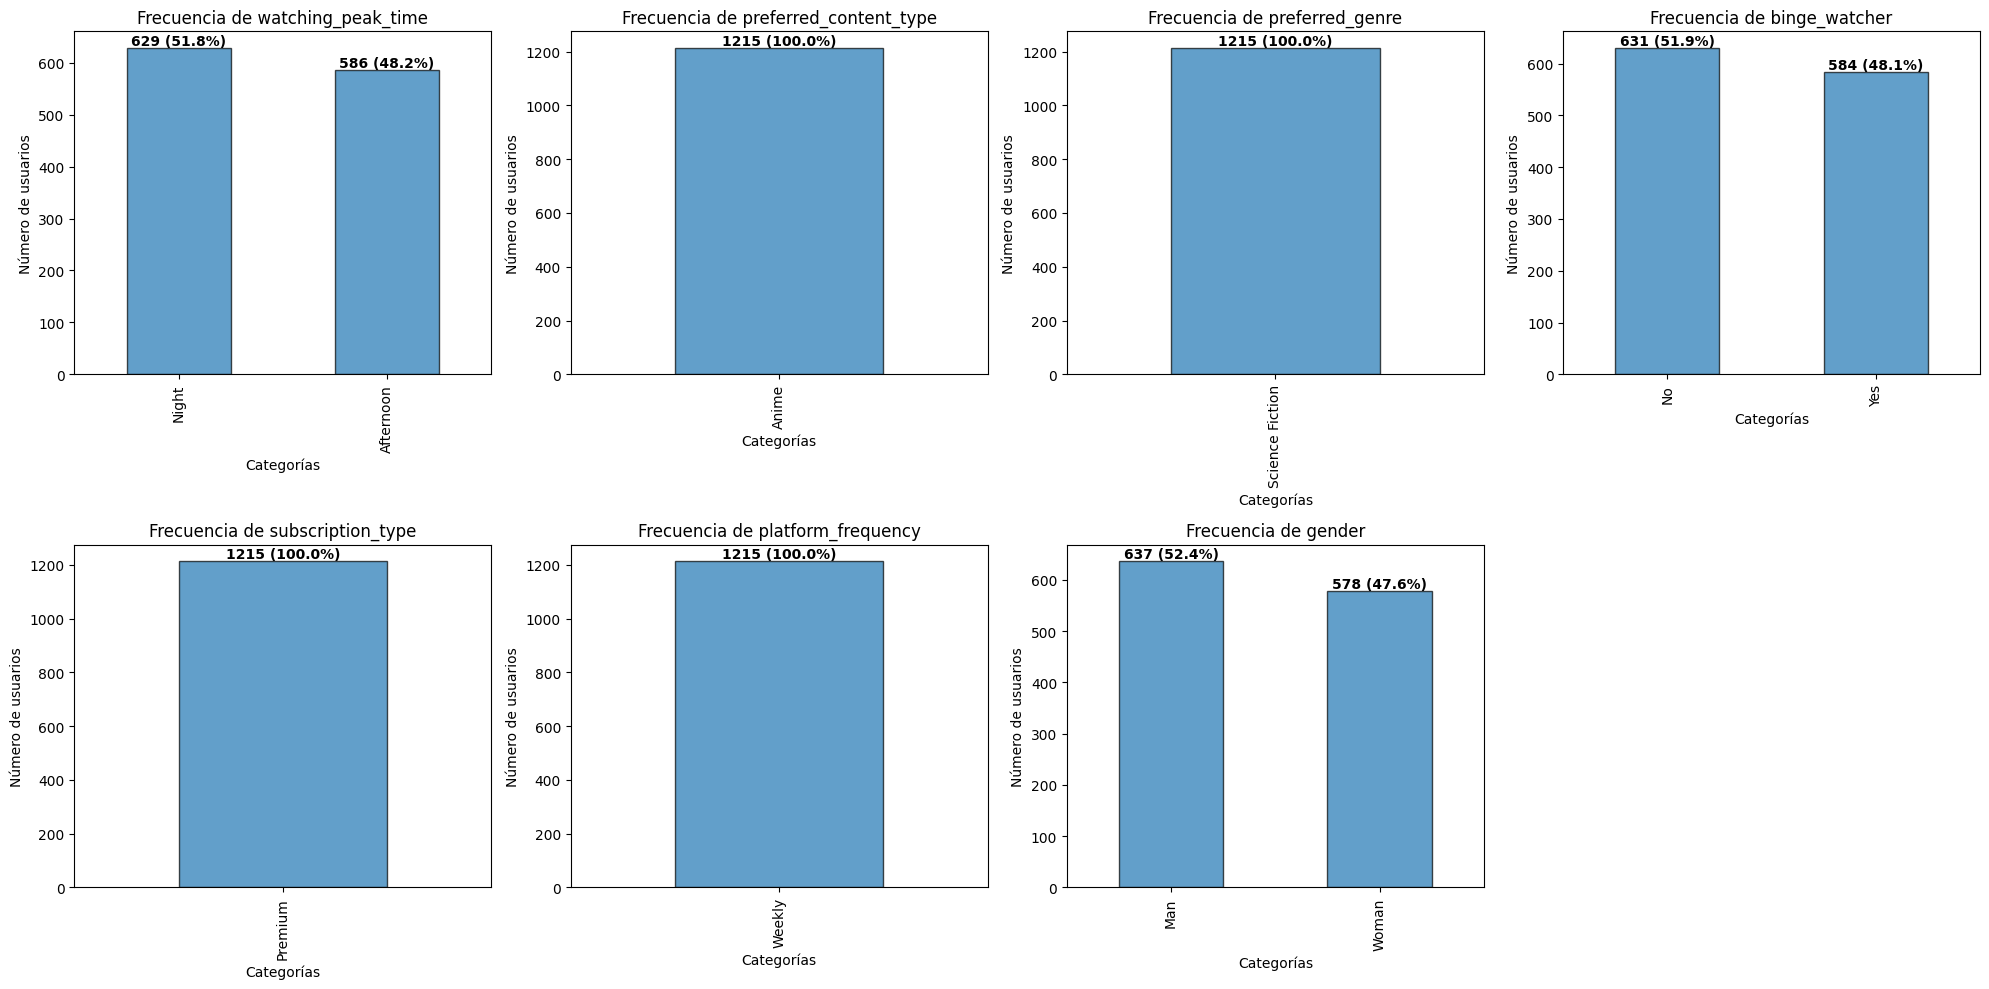

In [ ]:
graficar_cluster_hist(cluster_1, nombre='Clúster 1')

El **Clúster 1** está compuesto por hombres y mujeres en proporciones similares, con una franja de edad mayoritariamente entre los 25 y los 40 años. Todos tienen suscripción premium y acceden semanalmente. Prefieren contenido de anime y género de ciencia ficción. Su consumo mensual es medio, mayoritariamente ven contenido por la noche o por la tarde, y el hábito de hacer maratones está dividido a partes iguales.

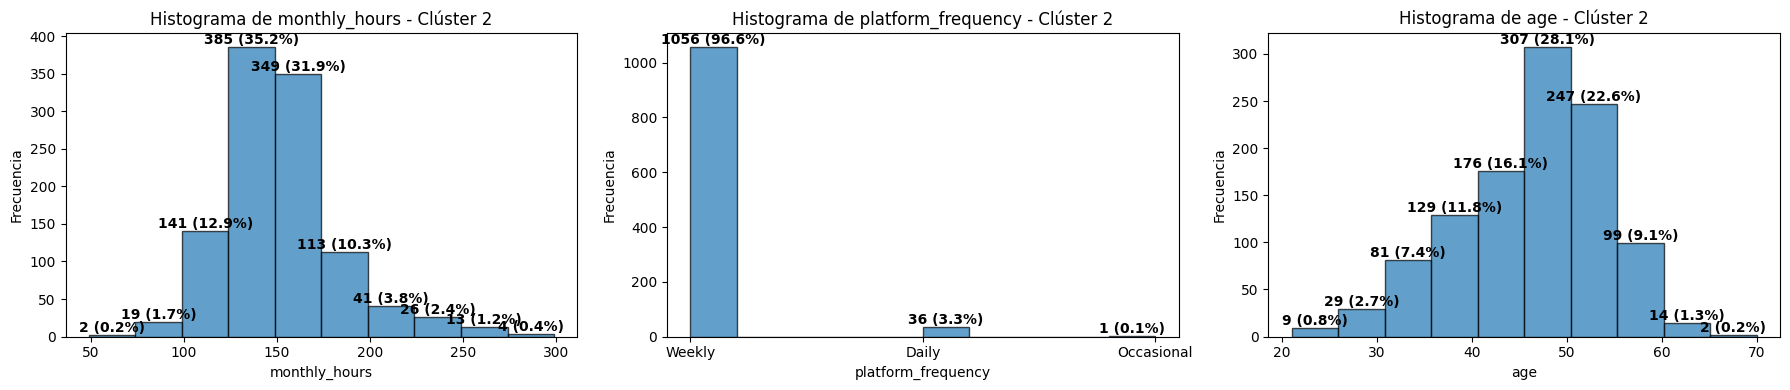

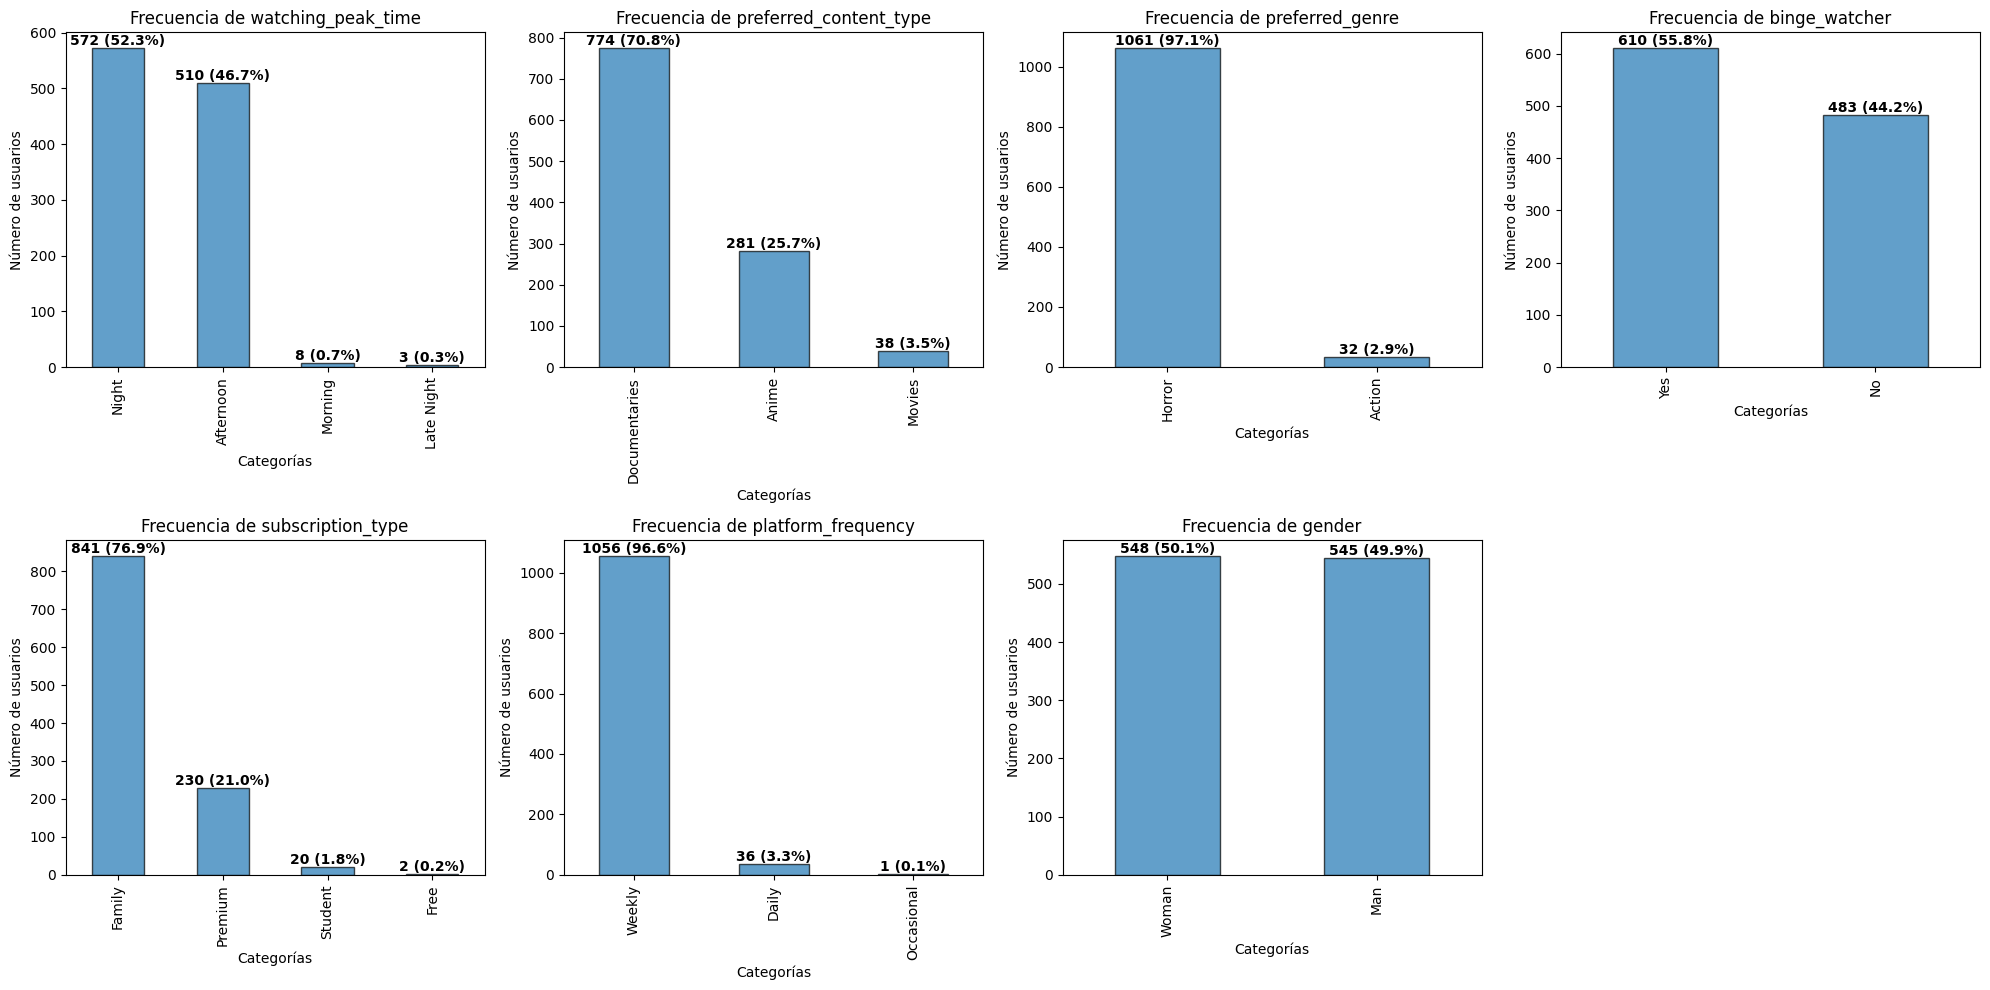

In [ ]:
graficar_cluster_hist(cluster_2, nombre='Clúster 2')

El **Clúster 2** está formado por hombres y mujeres en proporciones iguales, con una mayoría de usuarios adultos entre 40 y 55 años. Su consumo mensual es alto, acceden semanalmente y la mayoría tiene suscripción familiar. Prefieren contenido documental y del género de terror, con algo de interés por el anime. Suelen ver la plataforma por la noche o la tarde, y más de la mitad hacen maratones.

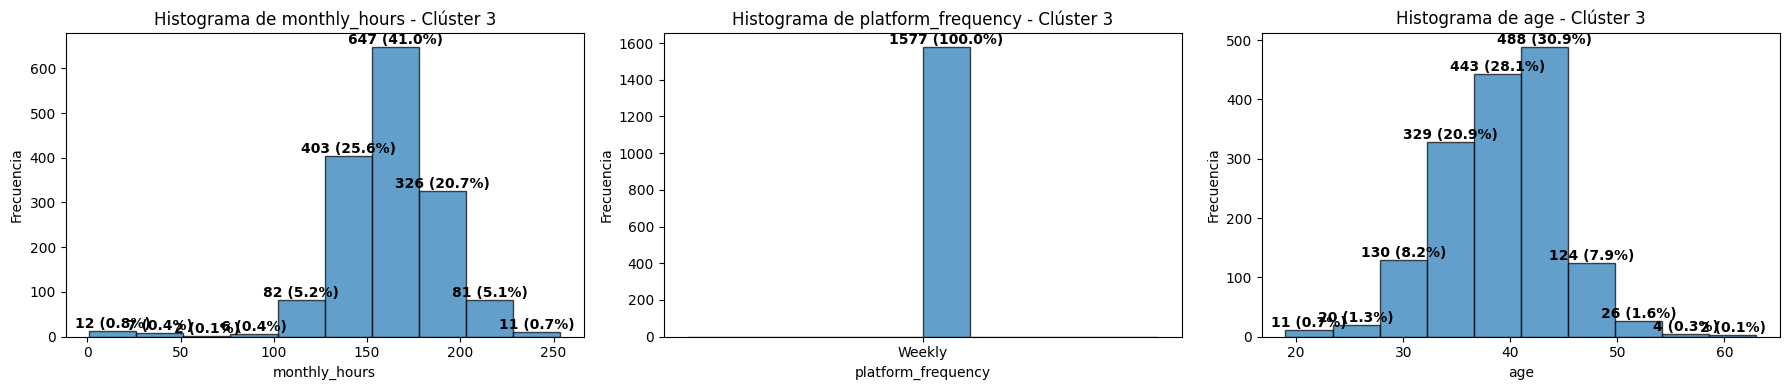

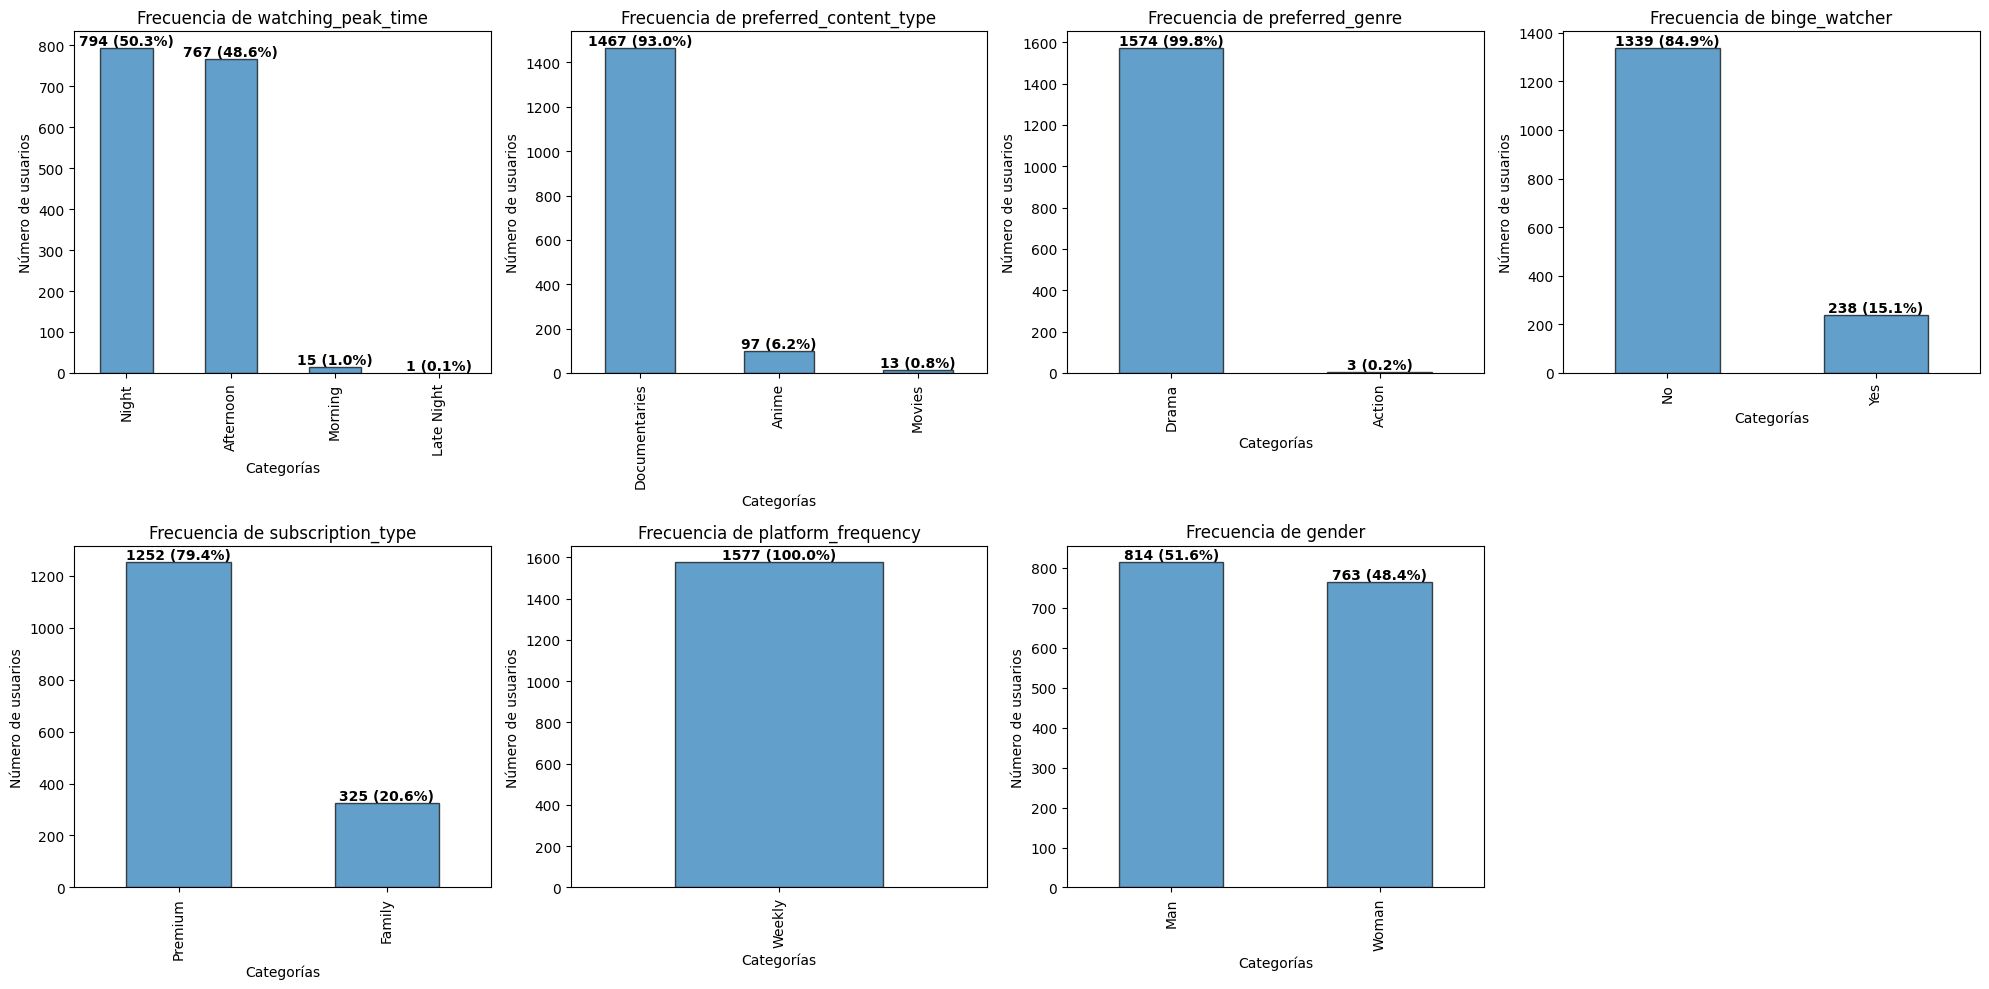

In [ ]:
graficar_cluster_hist(cluster_3, nombre='Clúster 3')

El **Clúster 3** está formado por usuarios adultos, en su mayoría entre 35 y 45 años, con acceso semanal y suscripción mayoritariamente premium. Consumen muchas horas al mes, prefieren documentales y género drama, y ven contenido principalmente por la noche o la tarde. La gran mayoría no hace maratones, lo que los diferencia de otros clústers.

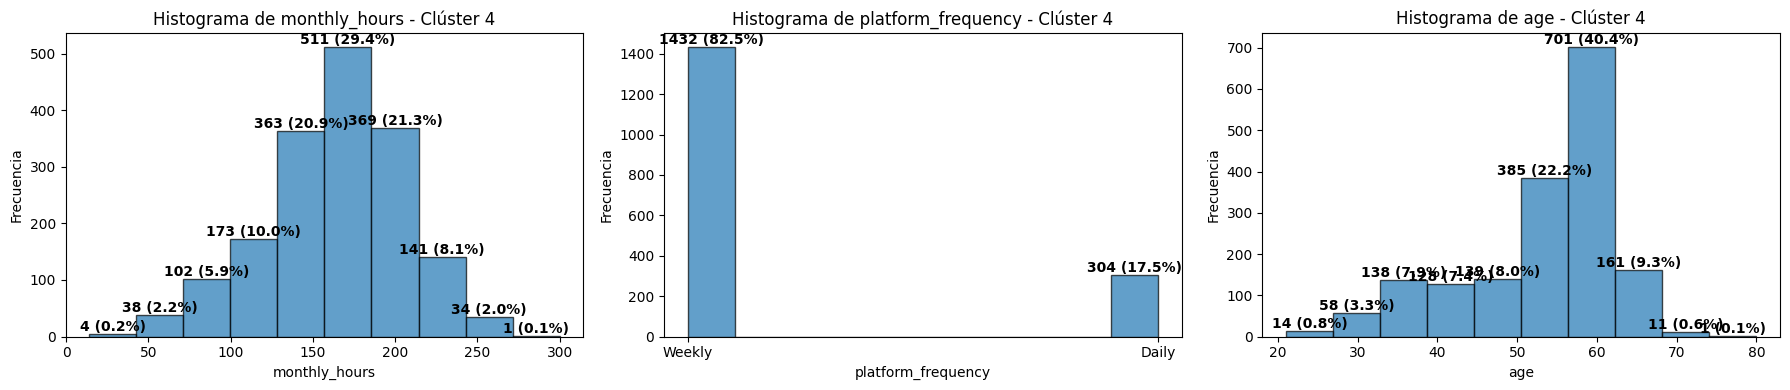

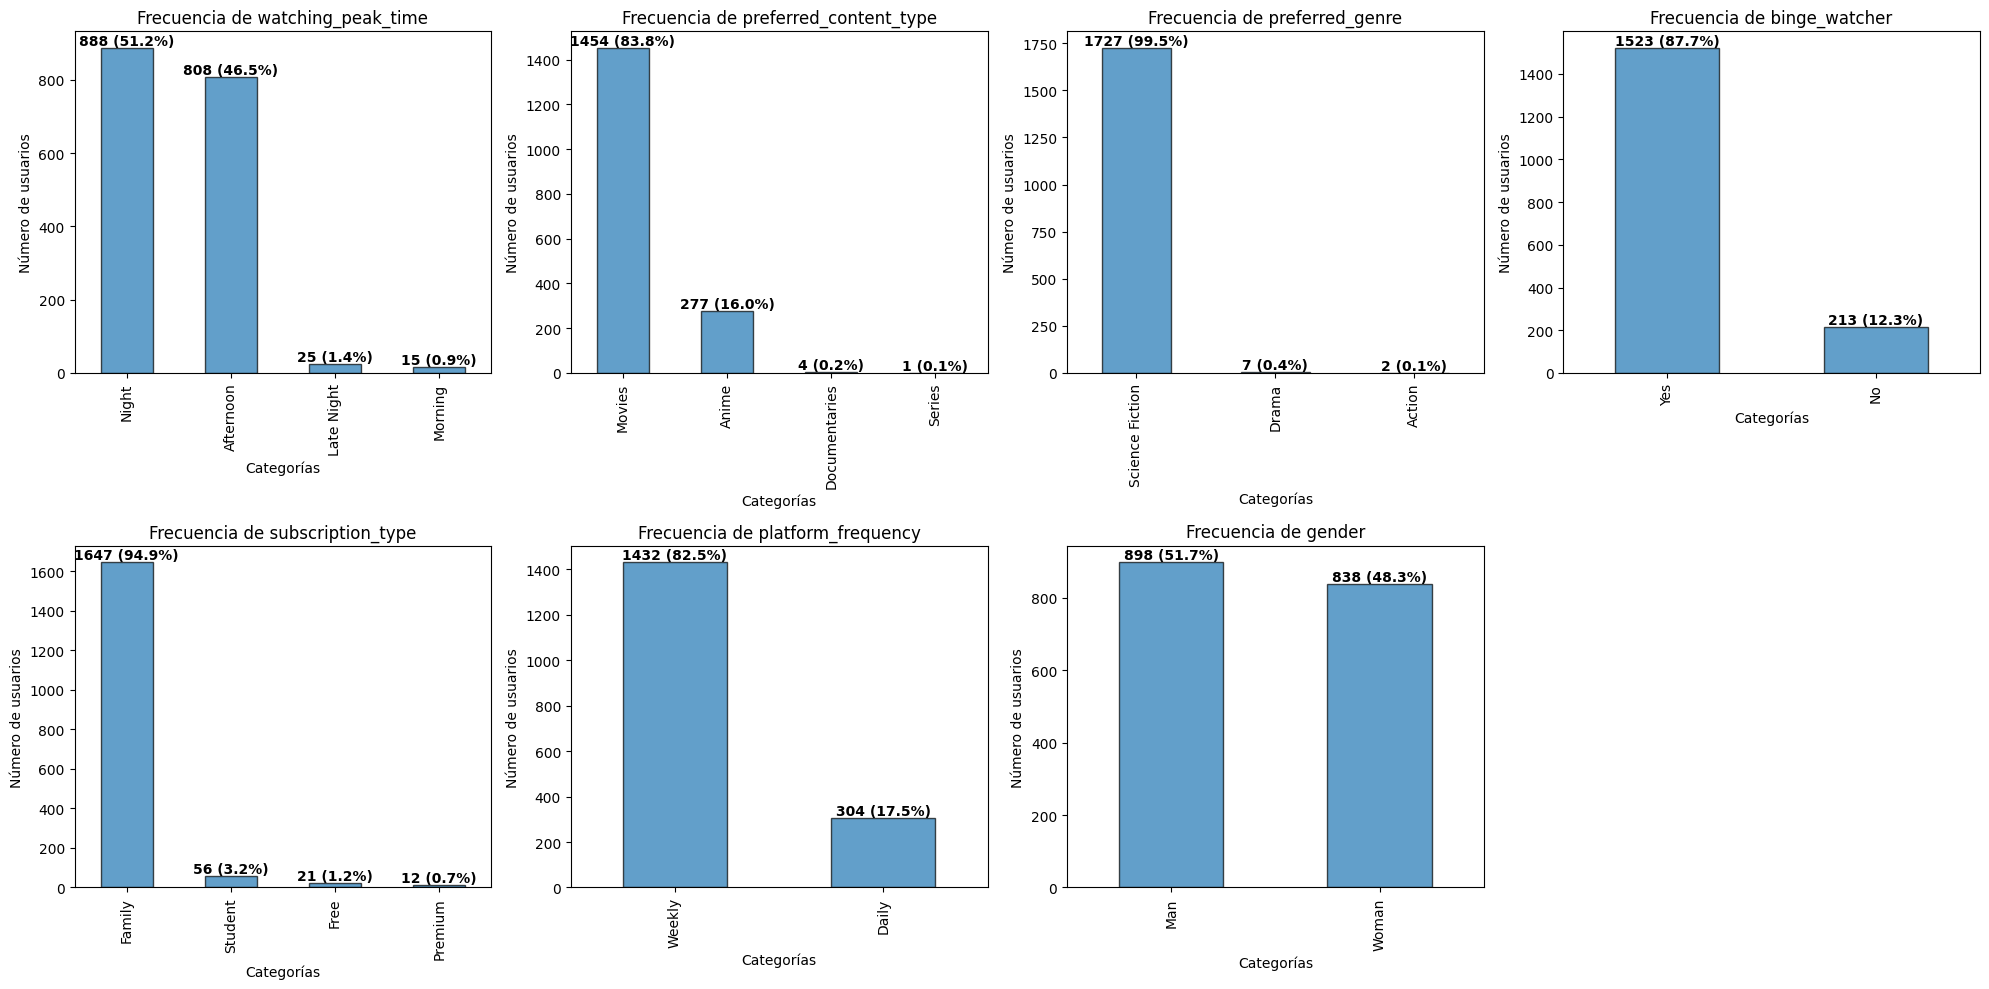

In [ ]:
graficar_cluster_hist(cluster_4, nombre='Clúster 4')

El **Clúster 4** está formado por usuarios mayores de 55 años, con acceso semanal o diario y suscripción mayoritariamente familiar. Consumen muchas horas al mes, prefieren películas y el género de ciencia ficción. Ven contenido principalmente por la noche o la tarde, y la gran mayoría realiza maratones.

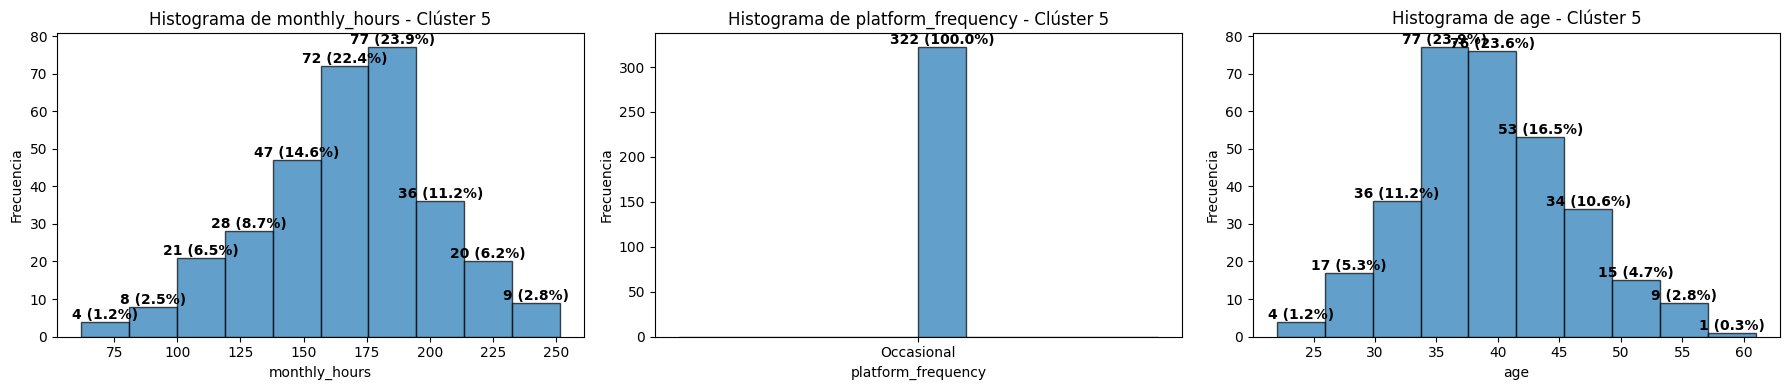

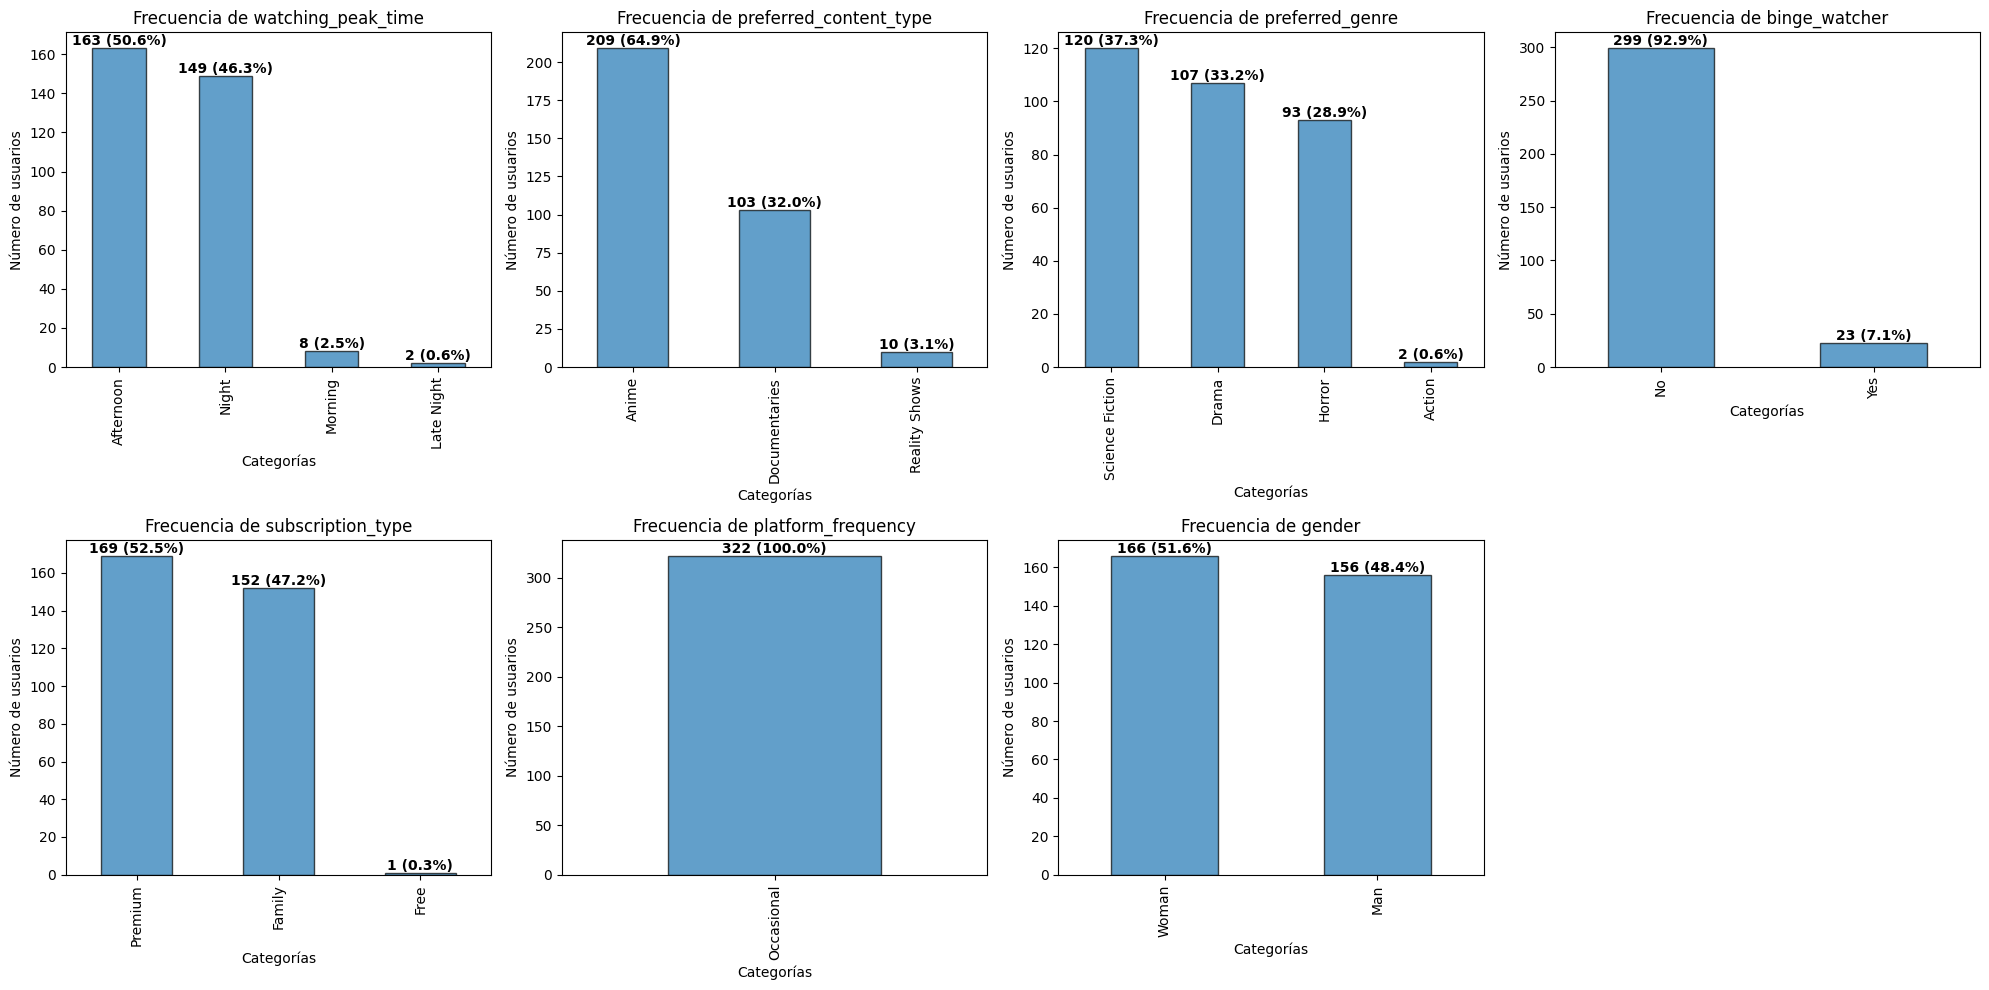

In [ ]:
graficar_cluster_hist(cluster_5, nombre='Clúster 5')

El **Clúster 5** agrupa usuarios de entre 30 y 45 años, con uso ocasional de la plataforma y consumo mensual alto. La mayoría tiene suscripción premium o familiar, no hacen maratones y prefieren contenido de anime o documentales. En cuanto a género, hay bastante equilibrio entre ciencia ficción, drama y terror, y ven contenido principalmente por la tarde o la noche.

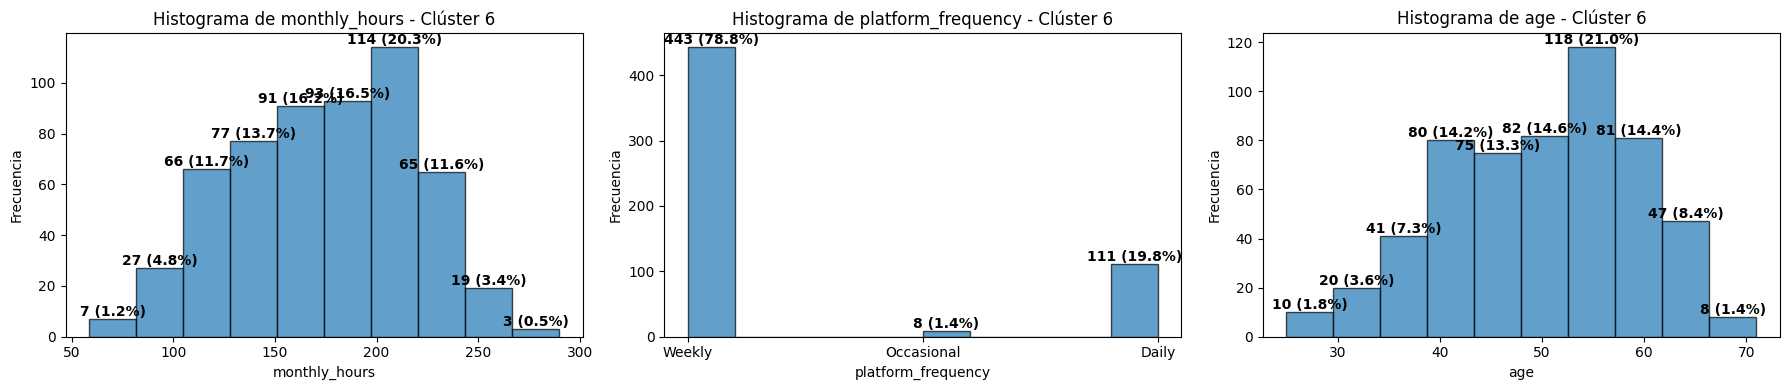

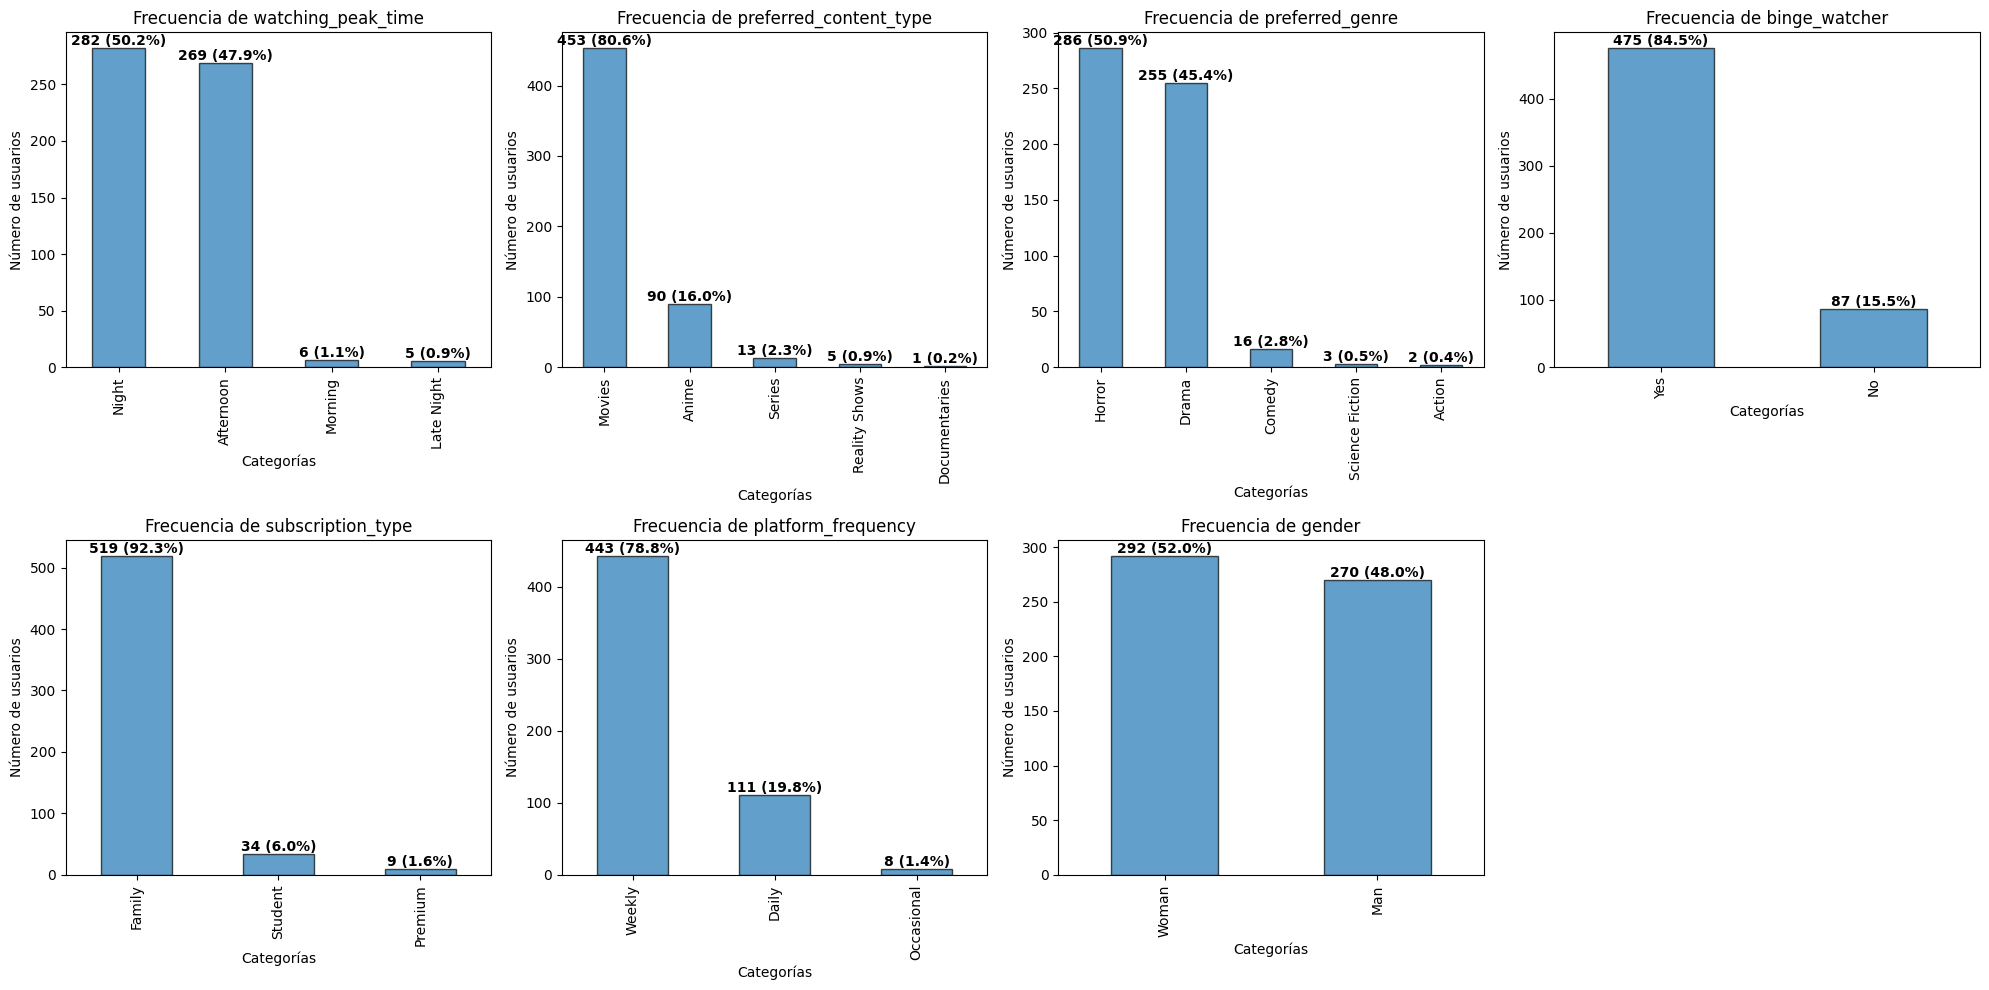

In [ ]:
graficar_cluster_hist(cluster_6, nombre='Clúster 6')

El **Clúster 6** agrupa usuarios de entre 45 y 60 años, con suscripción familiar y consumo semanal o diario. Prefieren películas, especialmente de terror y drama, ven contenido por la tarde o por la noche, y la gran mayoría hace maratones. Su consumo mensual es alto y el grupo está equilibrado en cuanto a género.

# CONCLUSIONES MÁS SIGNIFICATIVAS ENTRE CLÚSTERES

* El **Clúster 0** es el más numeroso (2524 usuarios), con mayoría de adultos entre 40 y 50 años, suscripción familiar, uso semanal alto y preferencia clara por documentales y ciencia ficción. **Es un grupo clave para fidelizar con contenido exclusivo, listas personalizadas y ventajas permanentes.**

* El **Clúster 4** (1736 usuarios) agrupa usuarios mayores de 50 años, con consumo mensual elevado, maratoneo frecuente y una clara inclinación por películas de ciencia ficción. **Su perfil consolidado permite trabajar la lealtad mediante recomendaciones automatizadas y beneficios en lanzamientos.**

* El **Clúster 3** (1577 usuarios) está compuesto por adultos de entre 35 y 45 años, mayoritariamente con suscripción premium. Tienen un consumo alto, acceden semanalmente y muestran preferencia por documentales y drama.** Son usuarios estables, adecuados para campañas basadas en contenido curado y estrenos premium.**

* El **Clúster 1** (1215 usuarios) representa un perfil más joven (25–40 años), con suscripción premium en el 100 % de los casos. Consumen anime y ciencia ficción, ven contenido por la noche o la tarde y hacen maratones de forma equilibrada. **Público ideal para promociones temáticas, estrenos exclusivos y gamificación.**

* El **Clúster 2** (1093 usuarios) es el más heterogéneo: mezcla suscripciones (premium, free y student), intereses variados (documentales, anime, terror) y uso semanal. **Requiere estrategias segmentadas, como pruebas gratuitas, recomendaciones por tipo de contenido o promociones rotativas.**

* El **Clúster 6** (562 usuarios) reúne usuarios de mediana edad (35–60 años), con suscripción familiar, consumo elevado y preferencia por terror y drama. La mayoría hace maratones y accede semanal o diariamente.** Grupo comprometido, ideal para campañas con contenido intenso y seriado.**

* El **Clúster 5** (322 usuarios) es el menos numeroso y con uso exclusivamente ocasional. Prefieren anime, documentales y géneros variados como ciencia ficción y drama, pero no suelen hacer maratones. **Grupo con bajo engagement: conviene activar con campañas puntuales, recompensas o novedades destacadas.**




# OTRAS CONCLUSIONES

Aunque las métricas iniciales indicaban que 7 era una opción razonable para el número de clústers, el análisis detallado muestra que algunos grupos comparten comportamientos muy similares. Esto plantea la posibilidad de fusionar ciertos clústers para obtener una segmentación más ágil, especialmente si el objetivo es simplificar las acciones de marketing o reducir la complejidad operativa.

Por ejemplo, los clústers 1 y 5 comparten un perfil joven con interés por el anime y la ciencia ficción, aunque se diferencian en la frecuencia de uso. También existe una fuerte similitud entre los clústers 0 y 4 en cuanto a consumo elevado, uso semanal y preferencia por la ciencia ficción, pese a variar ligeramente en la franja de edad.

Estos casos invitan a plantearse una segmentación alternativa con menos grupos, orientada a estrategias más amplias pero igualmente efectivas. No obstante, mantener los 7 clústers actuales permite capturar matices concretos del comportamiento de los usuarios y puede ser especialmente útil si se busca una personalización ajustada de contenidos, promociones o recomendaciones.

En definitiva, la decisión entre una segmentación más simplificada o más detallada dependerá del objetivo estratégico: si se prioriza la eficiencia y claridad operativa, podría ser adecuado reducir; si se busca máxima precisión y personalización, los 7 clústers actuales ofrecen una base sólida y diferenciada.
